# ROS2 介绍与安装

## Linux 与 Ubuntu

## Ubuntu 安装

## 常用终端指令
### ls命令
list 的缩写，查看 linux 文件夹包含的文件，而且可以查看文件权限(包括目录、文件夹、文件权限)查看目录信息等等。

常用参数搭配：

- ls -a   
列出目录所有文件，包含以.开始的隐藏文件
- ls -l   
除了文件名之外，还将文件的权限、所有者、文件大小等信息详细列出来

### cd 命令
cd(changeDirectory) 切换当前目录至 dirName。

命令语法：

cd [目录名]

- cd /   
进入根目录
- cd ~   
进入 "home" 目录

### pwd 命令
查看当前工作目录路径。

- pwd   
查看当前路径
- pwd -P   
查看软链接的实际路径

### mkdir 命令
用于创建文件夹。

可用选项：

-m: 对新建目录设置存取权限，也可以用 chmod 命令设置;  
-p: 可以是一个路径名称。此时若路径中的某些目录尚不存在,加上此选项后，系统将自动建立好那些尚不在的目录，即一次可以建立多个目录。  

- mkdir t   
当前工作目录下创建名为 t的文件夹
- mkdir -p /tmp/test/t1/t  
在 tmp 目录下创建路径为 test/t1/t 的目录，若不存在，则创建：

mkdir -p /tmp/test/t1/t

### rm 命令
删除一个目录中的一个或多个文件或目录，如果没有使用 -r 选项，则 rm 不会删除目录。如果使用 rm 来删除文件，通常仍可以将该文件恢复原状。

rm [选项] 文件…

- rm -i *.log  
删除任何 .log 文件，删除前逐一询问确认：
- rm -rf test  
删除 test 子目录及子目录中所有档案删除，并且不用一一确认：
- rm -- -f*  
删除以 -f 开头的文件

### mv命令
移动文件或修改文件名，根据第二参数类型（如目录，则移动文件；如为文件则重命令该文件）。

当第二个参数为目录时，第一个参数可以是多个以空格分隔的文件或目录，然后移动第一个参数指定的多个文件到第二个参数指定的目录中。

- mv test.log test1.txt  
将文件 test.log 重命名为 test1.txt
- mv log1.txt log2.txt log3.txt /test3   
将文件 log1.txt,log2.txt,log3.txt 移动到根的 test3 目录中
- mv -i log1.txt log2.txt  
将文件 file1 改名为 file2，如果 file2 已经存在，则询问是否覆盖
- mv * ../  
移动当前文件夹下的所有文件到上一级目录

### cp 命令
将源文件复制至目标文件，或将多个源文件复制至目标目录。

- cp a.txt b.txt  
复制 a.txt 到 test 目录下，保持原文件时间，如果原文件存在提示是否覆盖。

### touch命令
创建一个空文件或更新文件的时间戳（如果文件已存在）。

touch 文件名

## Ubantu 下载软件

## ROS2 介绍

## ROS1 与 ROS2

## ROS2安装
卸载
```
sudo apt remove ros-humble-*  
sudo apt autoremove
```

ROS2 安装地址  
/opt/ros/humble/

## ROS2系统架构
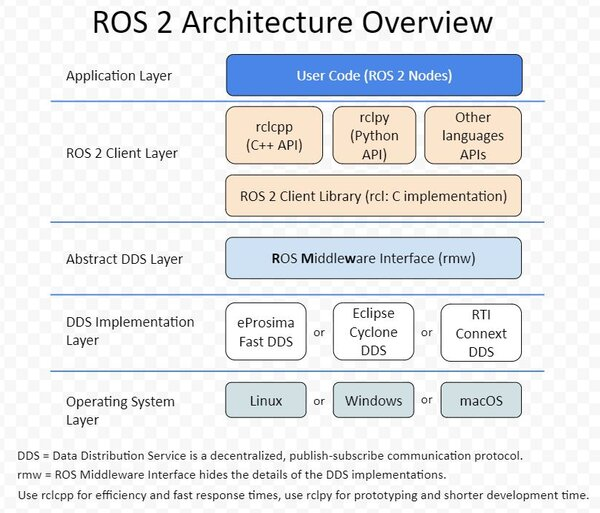

### 操作系统层
基于Linux、Windows或者macOS系统

### DDS实现层
DDS，全称 Data Distribution Service (数据分发服务)。是由对象管理组 (OMG) 于 2003 年发布并于 2007 年修订的开分布式系统标准。

通过类似于ROS中的话题发布和订阅形式来进行通信，同时提供了丰富的服务质量管理来保证可靠性、持久性、传输设置等。

DDS实现层其实就是对不同常见的DDS接口进行再次的封装，让其保持统一性，为DDS抽象层提供统一的API。

### 抽象DDS层-RMW
这一层将DDS实现层进一步的封装，使得DDS更容易使用。

原因在于DDS需要大量的设置和配置（分区，主题名称，发现模式，消息创建,...），这些设置都是在ROS2的抽象层中完成的。

### 客户端库-RCL
RCL（ROS Client Library）ROS客户端库，其实就是ROS的一种API，提供了对ROS话题、服务、参数、Action等接口

比如Python语言提供了rclpy来操作ROS2的节点话题服务等，而C++则使用rclcpp提供API操作ROS2的节点话题和服务等。

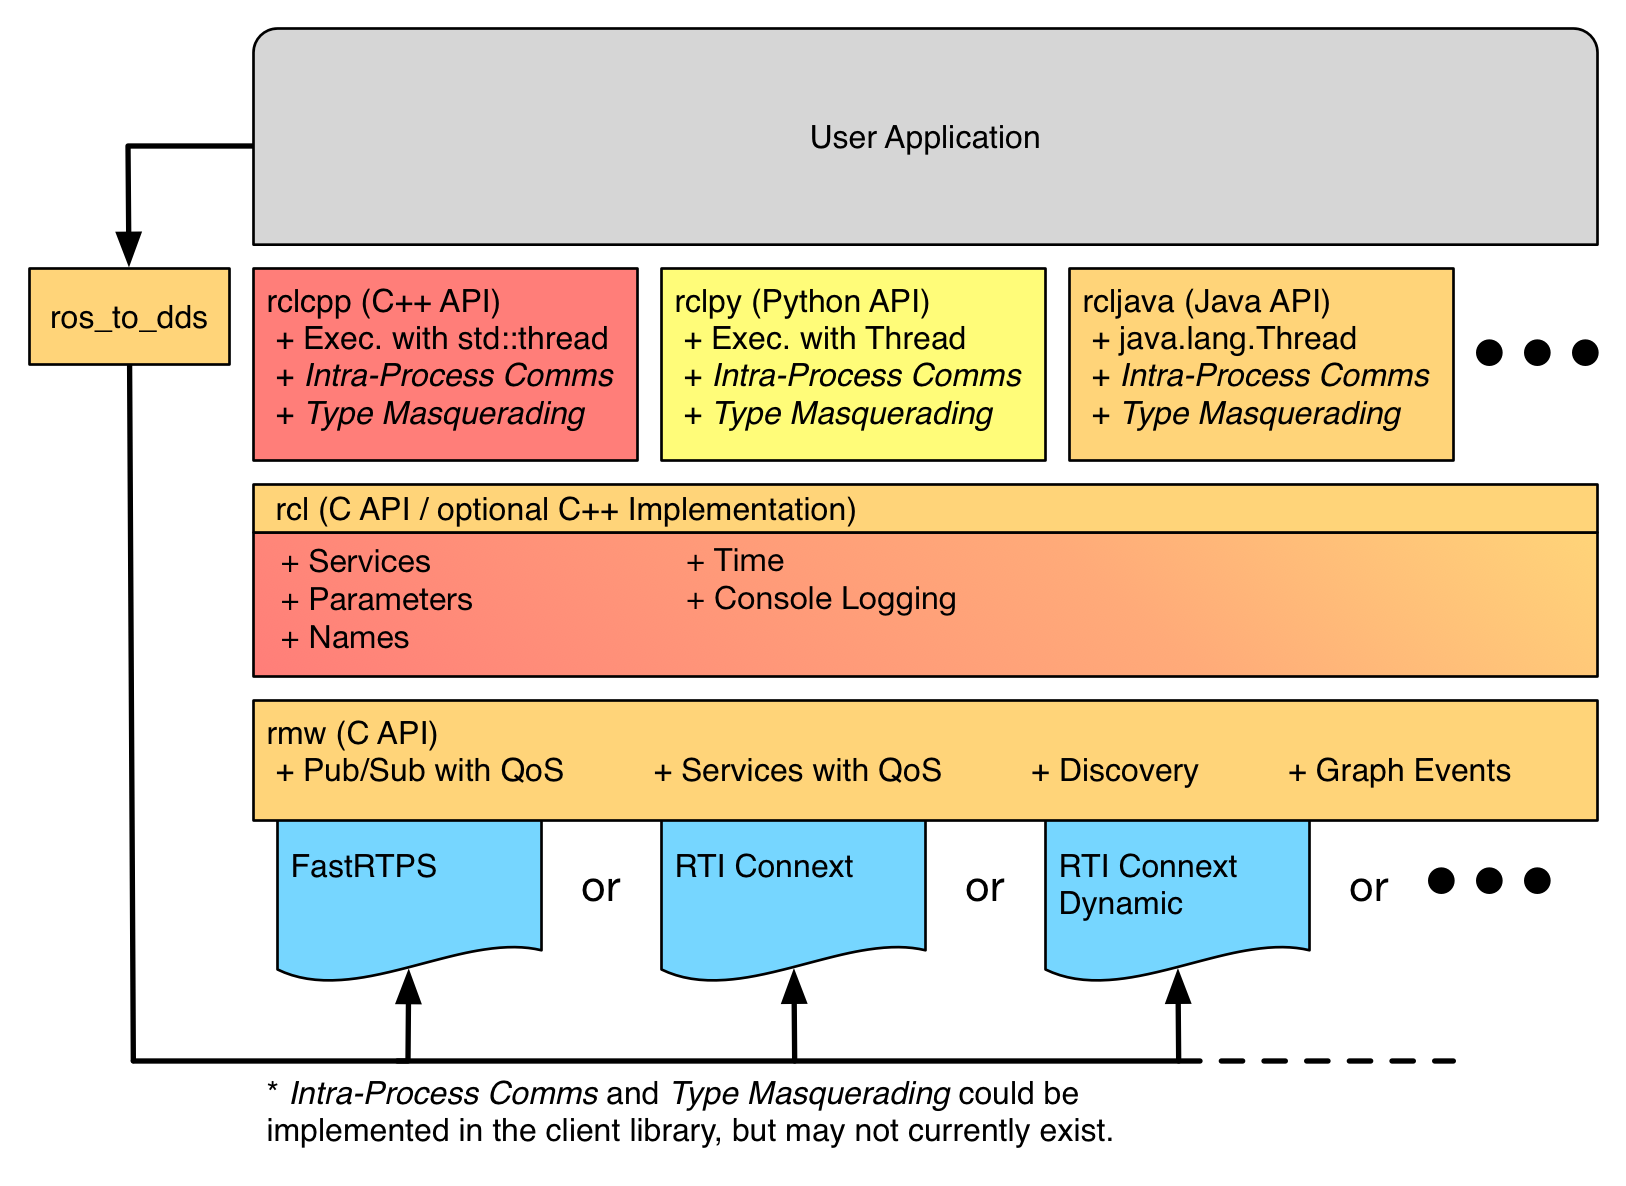

上面这张图是ROS2API的实现层级，最下面的是第三方的DDS

rmw（中间件接口）层是对各家DDS的抽象层，基于rmw实现了rclc，有了rclc，我们就可以实现各个语言的库

基于rclc，ROS2官方实现了rclpy和rclcpp

基于rclpy和rclcpp就可以实现上层的应用了

### 应用层
写代码以及ROS2开发的各种常用的机器人相关开发工具所在的层

## ROS2 中间件 DDS 架构
导论：DDS是什么、ROS2使用DDS所带来的优缺点  

### 什么是中间件

### ROS1 与 ROS2 中间件对比

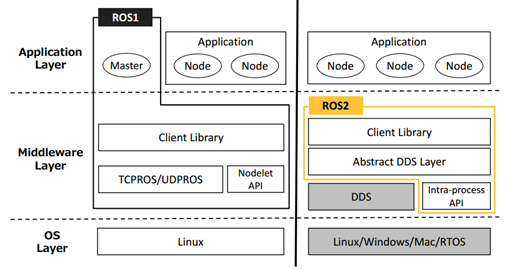

ROS1的中间件是ROS组织自己基于TCP/UDP机制建立的

ROS2采用了第三方的DDS作为中间件，将DDS服务接口进行了一层抽象，保证了上层应用层调用接口的统一性

基于DDS的互相发现协议，ROS2干掉了ROS1中的Master节点

ROS2为每家DDS供应商都开发了对应的DDS_Interface即DDS接口层，然后通过DDS Abstract抽象层来统一DDS的API

### DDS通信模型

### DDS优劣势

# 节点
ROS2中节点是只负责一个单独的模块化的功能（比如一个节点负责控制车轮转动，一个节点负责从激光雷达获取数据等等）  

节点与节点之间一共四种通信方式:
- 话题-topics
- 服务-services
- 动作-Action
- 参数-parameters

## 启动节点
```
ros2 run <package_name> <executable_name>
```

## 查看节点列表
```
ros2 node list
```

## 查看节点信息
```
ros2 node info <node_name>
```

## 重映射节点名称
```
ros2 run turtlesim turtlesim_node --ros-args --remap __node:=my_turtle
```

## 运行节点时设置参数
```
ros2 run example_parameters_rclcpp parameters_basic --ros-args -p rcl_log_level:=10
```

# 功能包与工作空间
运行一个节点的时候使用的是
```
ros2 run 包名字 可执行文件名字
```
我们想找到一个节点（可执行文件），就必须要先知道它在哪个包，那问题就来了，想要找到某个包，该去哪里找？

答案就是：工作空间

注意：一个工作空间下可以有多个功能包，一个功能包可以有多个节点存在

## 工作空间
工作空间是包含若干个功能包的目录，初学者可以把工作空间理解成一个文件夹。这个文件夹包含下有src。所以一般新建一个工作空间的操作就像下面一样
```
cd d2lros2/chapt2/
mkdir -p chapt2_ws/src
```

## 功能包
功能包可以理解为存放节点的地方，ROS2中功能包根据编译方式的不同分为三种类型。
- ament_python，适用于python程序
- cmake，适用于C++
- ament_cmake，适用于C++程序,是cmake的增强版

**获取功能包**  
1.安装  
```
sudo apt install ros-<version>-package_name
```
2.手动编译  
下载源码然后进行编译生成相关文件  
之后，需要手动source工作空间的install目录  

## 功能包相关命令
- 创建功能包
```
ros2 pkg create <package-name>  --build-type  {cmake,ament_cmake,ament_python}  --dependencies <依赖名字>
```

- 列出可执行文件
```
列出所有
ros2 pkg executables

列出turtlesim功能包的所有可执行文件
ros2 pkg executables turtlesim

列出所有的包
ros2 pkg list

输出某个包所在路径的前缀
ros2 pkg prefix  <package-name>

列出包的清单描述文件(查看小乌龟模拟器功能包的信息)
ros2 pkg xml turtlesim
```

# Colcon
一个功能包构建工具,简单点说就是用来编译代码的

## 安装
如果使用一键安装ROS2，会帮你安装好这个工具
终端安装
```
sudo apt-get install python3-colcon-common-extensions
```
安装完成后，打开终端输入colcon即可看到其使用方法

## 示例
创建一个工作区文件夹colcon_test_ws
```
cd d2lros2/chapt2/
mkdir colcon_test_ws && cd colcon_test_ws
```

下载个ROS2示例源码测试一下

```
git clone https://github.com/ros2/examples src/examples -b humble
```
编译工程
```
colcon build
```

编完之后的目录结构

构建完成后，在src同级目录我们应该会看到 build 、 install 和 log 目录:
```
.
├── build
├── install
├── log
└── src

4 directories, 0 files
```
- build 目录存储的是中间文件。对于每个包，将创建一个子文件夹，在其中调用例如CMake
- install 目录是每个软件包将安装到的位置。默认情况下，每个包都将安装到单独的子目录中。
- log 目录包含有关每个colcon调用的各种日志信息。



打开一个终端使用 cd colcon_test_ws进入我们刚刚创建的工作空间，先source 一下资源
```
source install/setup.bash
```

运行一个订者节点，你将看不到任何打印，因为没有发布者
```
ros2 run examples_rclcpp_minimal_subscriber subscriber_member_function
```

打开一个新的终端，先source，再运行一个发行者节点
```
source install/setup.bash
ros2 run examples_rclcpp_minimal_publisher publisher_member_function
```

## build参数
只编译一个包
```
colcon build --packages-select YOUR_PKG_NAME 
```
不编译测试单元
```
colcon build --packages-select YOUR_PKG_NAME  --cmake-args -DBUILD_TESTING=0
```
运行编译的包的测试
```
colcon test
```
允许通过更改src下的部分文件来改变install（重要）  
每次调整 python 脚本时都不必重新build了
```
colcon build --symlink-install
```


## 进阶
在之前我们用gcc编译了ROS2节点。其次，使用CMake（GCC或Makefile）和 Python Setup打包工具依然可以完成ROS2代码的编译，那为什么还需要Colcon呢？

两者的区分点在于针对的对象不同，构建系统针对一个单独的包进行构建，而构建工具重点在于按照依赖关系依次调用构建系统完成一系列功能包的构建。

ROS中用到的构建系统：CMake、ament_cmake、catkin、Python setuptools。

ROS中用到的构建工具：colcon、catkin_make、catkin_make_isolated、catkin_tools。

很明显colcon作为构建工具，通过调用CMake、Python setuptools完成构建。

### 常见构建系统
1. CMake  
CMake 是一个跨平台构建系统生成器。项目使用独立于平台的文件指定其生成过程。用户通过使用CMake为其平台上的本机工具生成构建系统来构建项目。   

2. Python setuptools  
setuptools是Python包的打包常用工具。Python 包使用文件来描述依赖项，以及如何构建和安装内容。  
在ROS2中，功能包可以是“普通”Python包，而在ROS1中，任何Python功能都是从CMake文件触发setup.py进行打包。  

3. catkin  
catkin基于CMake，并提供了一组方便的函数，使编写CMake包更容易。它自动生成 CMake 配置文件以及 pkg 配置文件。它还提供了注册不同类型测试的函数。  

### 常见构建工具
1. catkin_make  
该工具仅调用 CMake 一次，并使用 CMake 的函数在单个上下文中处理所有包。  
虽然这是一种有效的方法，因为所有包中的所有目标都可以并行化，但它具有明显的缺点。  
由于所有函数名称、目标和测试都共享一个命名空间，并且规模更大，这很容易导致冲突。  

2. colcon  
colcon是一个命令行工具，用于改进构建，测试和使用多个软件包的工作流程。它自动化了流程，处理了订购并设置了使用软件包的环境。  

3. ament_tools  
ament_tools由用于构建 ROS 2 包的独立 Python 3 包提供。它是为引导ROS 2项目而开发的，因此仅针对Python 3，并且可以在Linux，MacOS和Windows上运行。  
ament_tools支持构建以下软件包：
- 带有package.xml文件的 ROS 2 包。
- 带有package.xml普通的 CMake 包。
- 没有清单文件的普通 CMake 包（从 CMake 文件中提取包名称和依赖项）。
- 带有package.xml文件的 Python 包。
- 没有清单文件的 Python 包（从setup.py文件中提取包名称和依赖项）。

# 使用RCLCPP编写节点
节点需要存在于功能包当中、功能包需要存在于工作空间当中。所以我们要想创建节点，就要先创建一个工作空间，再创建功能包。

1.创建工作空间
```
cd d2lros2/chapt2/
mkdir -p chapt2_ws/src/
```

2.创建example_cpp功能包  
使用ament-cmake作为编译类型，并为其添加rclcpp依赖。
```
cd chapt2_ws/src
ros2 pkg create example_cpp --build-type ament_cmake --dependencies rclcpp
```
- pkg create 是创建包的意思
- --build-type 用来指定该包的编译类型，一共有三个可选项ament_python、ament_cmake、cmake
- --dependencies 指的是这个功能包的依赖，这里给了一个ros2的C++客户端接口rclcpp

创建完成后的目录结构如下：
```
.
└── src
    └── example_cpp
        ├── CMakeLists.txt
        ├── include
        │   └── example_cpp
        ├── package.xml
        └── src

5 directories, 2 files
```

3.创建节点
接着我们在example_cpp/src下创建一个node_01.cpp文件

4.编写代码
```c++
#include "rclcpp/rclcpp.hpp"


int main(int argc, char **argv)
{
    /* 初始化rclcpp  */
    rclcpp::init(argc, argv);
    /*产生一个node_01的节点*/
    auto node = std::make_shared<rclcpp::Node>("node_01");
    // 打印一句自我介绍
    RCLCPP_INFO(node->get_logger(), "node_01节点已经启动.");
    /* 运行节点，并检测退出信号 Ctrl+C*/
    rclcpp::spin(node);
    /* 停止运行 */
    rclcpp::shutdown();
    return 0;
}
```

5.修改CmakeLists  
在node_01.cpp中输入上面的内容后，还需要修改一下CMakeLists.txt。将其添加为可执行文件，并使用install指令将其安装到install目录。

在CmakeLists.txt最后一行加入下面两行代码。
```
add_executable(node_01 src/node_01.cpp)
ament_target_dependencies(node_01 rclcpp)
```
添加这两行代码的目的是让编译器编译node_01这个文件，接着在上面两行代码下面添加下面的代码。  
```
install(TARGETS
  node_01
  DESTINATION lib/${PROJECT_NAME}
)
```
6.编译运行节点  
在chapt2_ws下依次输入下面的命令  

编译节点  
```
colcon build
```
source环境  
```
source install/setup.bash
```
运行节点  
```
ros2 run example_cpp node_01
```
不出意外，你可以看到  

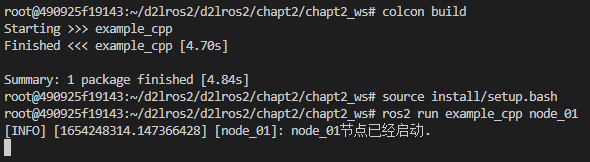

7.测试  
当节点运行起来后，可以再尝试使用``ros2 node list ``指令来查看现有的节点。这个时候你应该能看到：  

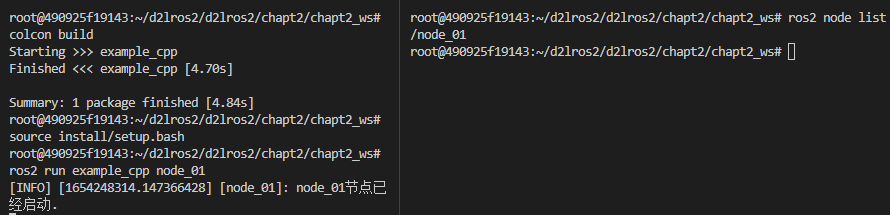

# 使用RCLPY编写节点

1.创建Python功能包  
创建一个名字叫做example_py python版本的功能包。
```
cd chapt2/chapt2_ws/src/
ros2 pkg create example_py  --build-type ament_python --dependencies rclpy
```
创建完成后的目录结构
```
.
├── example_py
│   └── __init__.py
├── package.xml
├── resource
│   └── example_py
├── setup.cfg
├── setup.py
└── test
    ├── test_copyright.py
    ├── test_flake8.py
    └── test_pep257.py

3 directories, 8 files
```

2.编写程序  
编写ROS2节点的一般步骤
>1. 导入库文件
>2. 初始化客户端库
>3. 新建节点
>4. spin循环节点
>5. 关闭客户端库

在example_py/example_py下创建node_02.py接着我们开始编写代码。
```py
import rclpy
from rclpy.node import Node

def main(args=None):
    """
    ros2运行该节点的入口函数
    编写ROS2节点的一般步骤
    1. 导入库文件
    2. 初始化客户端库
    3. 新建节点对象
    4. spin循环节点
    5. 关闭客户端库
    """
    rclpy.init(args=args) # 初始化rclpy
    node = Node("node_02")  # 新建一个节点
    node.get_logger().info("大家好，我是node_02.")
    rclpy.spin(node) # 保持节点运行，检测是否收到退出指令（Ctrl+C）
    rclpy.shutdown() # 关闭rclpy
```

代码编写完成用Crtl+S进行保存。接着修改setup.py：在entry_points中注册节点入口
```py
    entry_points={
        'console_scripts': [
            "node_02 = example_py.node_02:main"
        ],
    },
```
setup.py这段配置是声明一个ROS2的节点，声明后使用colcon build才能检测到，从而将其添加到install目录下。

3.编译运行节点
打开vscode终端，进入chapt2/chapt2_ws/

编译节点
```
cd chapt2/chapt2_ws/
colcon build
```

source环境
```
source install/setup.bash
```

运行节点
```
ros2 run example_py node_02
```

4.测试  
当节点运行起来后，可以再尝试使用ros2 node list 指令来查看现有的节点。

# 通信原理
通信的目的是在计算机系统中实现不同组件、进程或设备之间的信息和数据传递。通过通信，各个实体可以共享信息、协调行动并实现协同工作。  
在计算机领域，通信是构建分布式系统、网络和协议的基础。

通信的原理涉及两个主要方面：通信协议和通信方式。  
通信协议定义了数据的格式、传输方式、错误检测和纠正等规则，以确保可靠的数据传输。  
通信方式涉及了不同的通信介质和技术，包括网络通信和进程间通信（IPC）。  

1. 基于TCP/UDP的网络通信方式

基于TCP/UDP的网络通信方式通过计算机网络进行信息交换。  

其中，TCP（传输控制协议）提供可靠的、面向连接的通信，而UDP（用户数据报协议）则是无连接的通信方式。  

在Linux命令行中，可以使用诸如ping和nc命令来演示网络通信。

例如，使用ping命令进行基于UDP的网络通信：

>ping 192.168.0.1

该命令将向IP地址为192.168.0.1的主机发送ICMP Echo请求，并等待接收相应的回复。

使用nc命令进行基于TCP的网络通信：

>nc -l 1234

该命令将在本地监听端口1234，并等待与之建立TCP连接的客户端。通过在另一个终端窗口中执行以下命令，可以建立与本地1234端口的TCP连接并在连接上发送消息：

>echo "Hello, TCP!" | nc 127.0.0.1 1234

2. 基于共享内存的进程间通信（IPC）方式

基于共享内存的IPC方式通过共享内存区域在同一计算机系统内的不同进程之间进行通信。在Linux命令行中，可以使用ipcs和ipcrm命令来管理共享内存段。

通过ipcs命令查看当前系统中的共享内存段：

>ipcs -m

使用ipcrm命令删除不再需要的共享内存段：

>ipcrm -m <shmid>

# 话题 Topic
话题是ROS2中最常用的通信方式之一，话题通信采取的是订阅发布模型。

ROS2话题通信可以是，1对1，1对n，n对1，n对n的。

还有一种就是ROS2节点可以订阅本身发布的话题

## 消息接口
为了方便发送者和接收者进行数据的交换，ROS2帮我们在数据传递时做好了消息的序列化和反序列化，而且ROS2的消息序列化与反序列化通信是可以做到跨编程语言、跨平台和跨设备之间的。

ROS2如何做到跨编程语言、跨平台和跨设备之间的数据收发呢？这就得益于通过定义消息接口文件了。

当我们定义好消息接口后，ROS2会根据消息接口内容生成不同语言的接口类，在不同编程语言中调用相同的类即可实现无感的消息序列化和反序列化。

同一个话题，所有的发布者和接收者必须使用相同消息接口。

## 常用话题命令行
```
rqt_graph

ros2 topic -h

ros2 topic list

增加消息类型
ros2 topic list -t

ros2 topic echo打印实时话题内容
ros2 topic echo /chatter

ros2 topic info查看主题信息
ros2 topic info  /chatter

ros2 interface show查看消息类型
ros2 interface show std_msgs/msg/String
```

# RCLCPP实现话题
## 创建节点
我们将创建一个控制节点和一个被控节点。

控制节点创建一个话题发布者，发布控制命令（command）话题，接口类型为字符串（string），控制接点通过发布者发布控制命令（前进、后退、左转、右转、停止）。

被控节点创建一个订阅者，订阅控制命令，收到控制命令后根据命令内容打印。

依次输入下面的命令，创建chapt3_ws工作空间、example_topic_rclcpp功能包和topic_publisher_01.cpp
```
mkdir -p chapt3/chapt3_ws/src
cd chapt3/chapt3_ws/src
ros2 pkg create example_topic_rclcpp --build-type ament_cmake --dependencies rclcpp
touch example_topic_rclcpp/src/topic_publisher_01.cpp
```
--build-type ament_cmake：指定功能包的构建类型为 ament_cmake，这是 ROS 2 中用于 C++ 项目的主流构建系统（基于 CMake）。

--dependencies rclcpp：指定功能包的依赖项为 rclcpp（ROS 2 的 C++ 客户端库，用于编写 C++ 节点）。

完成后目录结构
```
.
└── src
    └── example_topic_rclcpp
        ├── CMakeLists.txt
        ├── include
        │   └── example_topic_rclcpp
        ├── package.xml
        └── src
            └── topic_publisher_01.cpp

5 directories, 3 files
```

接着采用面向对象方式写一个最简单的节点(topic_publisher_01.cpp)。
```
#include "rclcpp/rclcpp.hpp"

class TopicPublisher01 : public rclcpp::Node
{
public:
    // 构造函数,有一个参数为节点名称
    TopicPublisher01(std::string name) : Node(name)
    {
        RCLCPP_INFO(this->get_logger(), "%s节点已经启动.", name.c_str());
    }

private:
    // 声明节点
};

int main(int argc, char **argv)
{
    rclcpp::init(argc, argv);
    /*创建对应节点的共享指针对象*/
    auto node = std::make_shared<TopicPublisher01>("topic_publisher_01");
    /* 运行节点，并检测退出信号*/
    rclcpp::spin(node);
    rclcpp::shutdown();
    return 0;
}
```

修改CMakeLists.txt
```
add_executable(topic_publisher_01 src/topic_publisher_01.cpp)
ament_target_dependencies(topic_publisher_01 rclcpp)

install(TARGETS
  topic_publisher_01
  DESTINATION lib/${PROJECT_NAME}
)
```
add_executable：指定将 src/topic_publisher_01.cpp 编译为名为 topic_publisher_01 的可执行文件。

ament_target_dependencies：将可执行文件与 rclcpp 库链接（必须与 find_package 声明的依赖对应）。

install(TARGETS ...)：将编译好的可执行文件安装到 ROS 2 约定的路径（lib/${PROJECT_NAME}），确保 ros2 run 命令能找到该节点。

接着可以编译测试下，注意运行colcon的目录。
```
cd chapt3/chapt3_ws/
colcon build --packages-select example_topic_rclcpp
source install/setup.bash
ros2 run example_topic_rclcpp topic_publisher_01
```
--packages-select example_topic_rclcpp：指定只编译 example_topic_rclcpp 这一个功能包（而不是编译工作空间中所有功能包）。

source install/setup.bash:加载工作空间的环境变量配置文件。

编译后生成的可执行文件、功能包路径等信息会写入 install/setup.bash，执行 source 后，系统才能找到这些资源（比如让 ros2 run 命令识别到你编译的节点）。

注意：每次新开终端或重新编译后，都需要执行该命令才能生效（或配置终端自动加载）。

## 编写发布者
想要创建发布者，只需要调用node的成员函数create_publisher并传入对应的参数即可

我们至少需要传入消息类型（msgT）、话题名称（topic_name）和 服务指令（qos）

**导入消息接口**  

消息接口是ROS2通信时必须的一部分，通过消息接口ROS2才能完成消息的序列化和反序列化。

ROS2为我们定义好了常用的消息接口，并生成了C++和Python的依赖文件，我们可以直接在程序中进行导入。

ament_cmake类型功能包导入消息接口分为三步：

- 在CMakeLists.txt中导入，具体是先find_packages再ament_target_dependencies。

- 在packages.xml中导入，具体是添加depend标签并将消息接口写入。

- 在代码中导入，C++中是#include"消息功能包/xxx/xxx.hpp"。

我们依次做完这三步后文件内容如下：

CMakeLists.txt
```
find_package(rclcpp REQUIRED)
find_package(std_msgs REQUIRED)

ament_target_dependencies(topic_publisher_01 rclcpp std_msgs)
```

packages.xml
```
  <depend>rclcpp</depend>
  <depend>std_msgs</depend>
```

代码文件topic_publisher_01.cpp
```
#include "rclcpp/rclcpp.hpp"
#include "std_msgs/msg/string.hpp"

class TopicPublisher01 : public rclcpp::Node
```

**定时器**

我们需要通过ROS2中的定时器来设置指定的周期调用回调函数，在回调函数里实现发布数据功能

定时器函数参数

- period，回调函数调用周期。
- callback，回调函数。
- group，调用回调函数所在的回调组，默认为nullptr。

定时器对应的类是 rclcpp::TimerBase，调用create_wall_timer将返回其共享指针。

创建定时器时传入了两个参数，这两个参数都利用了C++11的新特性。

>std::chrono::milliseconds(500)，代表500ms，chrono是c++ 11中的时间库，提供计时，时钟等功能。  
>std::bind(&TopicPublisher01::timer_callback, this)，bind() 函数的意义就像它的函数名一样，是用来绑定函数调用的某些参数的。

ROS2会将消息文件转换成一个类，并把其中的定义转换成类的成员函数。

修改后的topic_publisher_01.cpp如下
```
#include "rclcpp/rclcpp.hpp"
#include "std_msgs/msg/string.hpp"

class TopicPublisher01 : public rclcpp::Node
{
public:
    // 构造函数,有一个参数为节点名称
    TopicPublisher01(std::string name) : Node(name)
    {
        RCLCPP_INFO(this->get_logger(), "大家好，我是%s.", name.c_str());
        // 创建发布者
        command_publisher_ = this->create_publisher<std_msgs::msg::String>("command", 10);
        // 创建定时器，500ms为周期，定时发布
        timer_ = this->create_wall_timer(std::chrono::milliseconds(500), std::bind(&TopicPublisher01::timer_callback, this));
    }

private:
    void timer_callback()
    {
        // 创建消息
        std_msgs::msg::String message;
        message.data = "forward";
        // 日志打印
        RCLCPP_INFO(this->get_logger(), "Publishing: '%s'", message.data.c_str());
        // 发布消息
        command_publisher_->publish(message);
    }
    // 声名定时器指针
    rclcpp::TimerBase::SharedPtr timer_;
    // 声明话题发布者指针
    rclcpp::Publisher<std_msgs::msg::String>::SharedPtr command_publisher_;
};
```

编译，source，运行
```
cd chapt3/chapt3_ws/
colcon build --packages-select example_topic_rclcpp
source install/setup.bash
ros2 run example_topic_rclcpp topic_publisher_01
```

## 编写订阅者
创建订阅节点
```
cd chapt3_ws/src/example_topic_rclcpp
touch src/topic_subscribe_01.cpp
```

编写代码
```
#include "rclcpp/rclcpp.hpp"

class TopicSubscribe01 : public rclcpp::Node
{
public:
    // 构造函数,有一个参数为节点名称
    TopicSubscribe01(std::string name) : Node(name)
    {
        RCLCPP_INFO(this->get_logger(), "大家好，我是%s.", name.c_str());
    }

private:
    // 声明节点
};

int main(int argc, char **argv)
{
    rclcpp::init(argc, argv);
    /*创建对应节点的共享指针对象*/
    auto node = std::make_shared<TopicSubscribe01>("topic_subscribe_01");
    /* 运行节点，并检测退出信号*/
    rclcpp::spin(node);
    rclcpp::shutdown();
    return 0;
}
```

CMakeLists.txt
```
add_executable(topic_subscribe_01 src/topic_subscribe_01.cpp)
ament_target_dependencies(topic_subscribe_01 rclcpp)

install(TARGETS
topic_subscribe_01
  DESTINATION lib/${PROJECT_NAME}
)
```

编译测试
```
cd chapt3/chapt3_ws/
colcon build --packages-select example_topic_rclcpp
source install/setup.bash
ros2 run example_topic_rclcpp topic_subscribe_01
```

五个参数，但后面两个都是默认的参数，我们只需要有话题名称、Qos和回调函数即可

继续编写代码
```
#include "rclcpp/rclcpp.hpp"
#include "std_msgs/msg/string.hpp"

class TopicSubscribe01 : public rclcpp::Node
{
public:
    // 构造函数,有一个参数为节点名称
    TopicSubscribe01(std::string name) : Node(name)
    {
        RCLCPP_INFO(this->get_logger(), "大家好，我是%s.", name.c_str());
        // 创建一个订阅者订阅话题
        command_subscribe_ = this->create_subscription<std_msgs::msg::String>("command", 10, std::bind(&TopicSubscribe01::command_callback, this, std::placeholders::_1));
    }

private:
     // 声明一个订阅者
    rclcpp::Subscription<std_msgs::msg::String>::SharedPtr command_subscribe_;
     // 收到话题数据的回调函数
    void command_callback(const std_msgs::msg::String::SharedPtr msg)
    {
        double speed = 0.0f;
        if(msg->data == "forward")
        {
            speed = 0.2f;
        }
        RCLCPP_INFO(this->get_logger(), "收到[%s]指令，发送速度 %f", msg->data.c_str(),speed);
    }
};

int main(int argc, char **argv)
{
    rclcpp::init(argc, argv);
    /*创建对应节点的共享指针对象*/
    auto node = std::make_shared<TopicSubscribe01>("topic_subscribe_01");
    /* 运行节点，并检测退出信号*/
    rclcpp::spin(node);
    rclcpp::shutdown();
    return 0;
}
```

依然的需要在CMakeLists.txt添加下std_msgs依赖
```
ament_target_dependencies(topic_subscribe_01 rclcpp std_msgs)
```

packages.xml就不需要了，同一个功能包，已经添加了。

编译运行订阅节点
```
cd chapt3/chapt3_ws/
colcon build --packages-select example_topic_rclcpp
source install/setup.bash
ros2 run example_topic_rclcpp topic_subscribe_01
```

手动发布数据测试订阅者
```
ros2 topic pub /command std_msgs/msg/String "{data: forward}"
```

## 订阅发布测试
关闭上面启动的终端，重新运行指令
```
cd chapt3/chapt3_ws/
source install/setup.bash
ros2 run example_topic_rclcpp topic_subscribe_01

cd chapt3/chapt3_ws/
source install/setup.bash
ros2 run example_topic_rclcpp topic_publisher_01

rqt
```

# RCLPY实现话题
1. 创建功能包和节点
```
cd chapt3/chapt3_ws/src/
ros2 pkg create example_topic_rclpy  --build-type ament_python --dependencies rclpy

cd example_topic_rclpy/example_topic_rclpy
touch topic_subscribe_02.py
touch topic_publisher_02.py
```

对应的文件结构如下
```
example_topic_rclpy/                  # 包根目录
├── example_topic_rclpy/              # Python模块目录（必须与包名一致）
│   ├── __init__.py                   # 空文件，标记为Python模块
│   ├── topic_publisher_02.py         # 发布者节点
│   └── topic_subscribe_02.py         # 订阅者节点
├── setup.py                          # 需修改的配置文件
└── package.xml                       # 包信息文件（无需额外改，除非加依赖）
```

2. 编写发布者
```
#!/usr/bin/env python3
import rclpy
from rclpy.node import Node
from std_msgs.msg import String

class NodePublisher02(Node):
    def __init__(self,name):
        super().__init__(name)
        self.get_logger().info("大家好，我是%s!" % name)
        # -----创建发布者-----
        self.command_publisher_ = self.create_publisher(String,"command", 10) 
        self.timer = self.create_timer(0.5, self.timer_callback)
        # --------------------

    # --------创建定时器------------
    def timer_callback(self):
        """
        定时器回调函数
        """
        msg = String()
        msg.data = 'backup'
        self.command_publisher_.publish(msg) 
        self.get_logger().info(f'发布了指令：{msg.data}')    #打印一下发布的数据
    # -----------------------------    

def main(args=None):
    rclpy.init(args=args) # 初始化rclpy
    node = NodePublisher02("topic_publisher_02")  # 新建一个节点
    rclpy.spin(node) # 保持节点运行，检测是否收到退出指令（Ctrl+C）
    rclpy.shutdown() # 关闭rclpy
```

3. 编写订阅者
```
#!/usr/bin/env python3
import rclpy
from rclpy.node import Node
from std_msgs.msg import String

class NodeSubscribe02(Node):
    def __init__(self,name):
        super().__init__(name)
        self.get_logger().info("大家好，我是%s!" % name)
        # -----创建订阅者-----
        self.command_subscribe_ = self.create_subscription(String,"command",self.command_callback,10)

    # --------------------
    def command_callback(self,msg):
        speed = 0.0
        if msg.data=="backup":
            speed = -0.2
        self.get_logger().info(f'收到[{msg.data}]命令，发送速度{speed}')
    # --------------------

def main(args=None):
    rclpy.init(args=args) # 初始化rclpy
    node = NodeSubscribe02("topic_subscribe_02")  # 新建一个节点
    rclpy.spin(node) # 保持节点运行，检测是否收到退出指令（Ctrl+C）
    rclpy.shutdown() # 关闭rclpy    

```

4. 修改setup.py
```
    entry_points={
        'console_scripts': [
            "topic_publisher_02 = example_topic_rclpy.topic_publisher_02:main",
            "topic_subscribe_02 = example_topic_rclpy.topic_subscribe_02:main"
        ],
    },
```

5. 运行测试
```
cd chapt3/chapt3_ws/
colcon build --packages-select example_topic_rclpy
source install/setup.bash
ros2 run example_topic_rclpy topic_publisher_02

cd chapt3/chapt3_ws/
source install/setup.bash
ros2 run example_topic_rclpy topic_subscribe_02

rqt
```

# 服务 Service
服务-客户端模型，即请求-响应模型

话题是没有返回的，适用于单向或大量的数据传递。而服务是双向的，客户端发送请求，服务端响应请求。

注意
- 同一个服务（名称相同）有且只能有一个节点来提供
- 同一个服务可以被多个客户端调用

## 示例
打开终端，运行下面的命令，这个命令用于运行一个服务节点，这个服务的功能是将两个数字相加，给定a，b两个数，返回sum也就是ab之和
```
ros2 run examples_rclpy_minimal_service service
ros2 service list

ros2 service call /add_two_ints example_interfaces/srv/AddTwoInts "{a: 5,b: 10}"
```

## 服务常用命令行
```
ros2 service list

手动调用服务
ros2 service call /add_two_ints example_interfaces/srv/AddTwoInts "{a: 5,b: 10}"

查看服务接口类型
ros2 service type /add_two_ints

查找使用某一接口的服务
ros2 service find example_interfaces/srv/AddTwoInts

# RCLCPP实现服务
## 创建功能包和节点
```
cd chapt3/chapt3_ws/src
ros2 pkg create example_service_rclcpp --build-type ament_cmake --dependencies rclcpp
touch example_service_rclcpp/src/service_server_01.cpp
touch example_service_rclcpp/src/service_client_01.cpp
```

面向对象方式写两个最简单的节点   

In [ ]:
//service_server_01.cpp

#include "rclcpp/rclcpp.hpp"

class ServiceServer01 : public rclcpp::Node {
public:
  ServiceServer01(std::string name) : Node(name) {
    RCLCPP_INFO(this->get_logger(), "节点已启动：%s.", name.c_str());
  }

private:
};

int main(int argc, char** argv) {
  rclcpp::init(argc, argv);
  auto node = std::make_shared<ServiceServer01>("service_server_01");
  rclcpp::spin(node);
  rclcpp::shutdown();
  return 0;
}

In [ ]:
//service_client_01.cpp

#include "rclcpp/rclcpp.hpp"

class ServiceClient01 : public rclcpp::Node {
public:
  // 构造函数,有一个参数为节点名称
  ServiceClient01(std::string name) : Node(name) {
    RCLCPP_INFO(this->get_logger(), "节点已启动：%s.", name.c_str());
  }
private:
};

int main(int argc, char** argv) {
  rclcpp::init(argc, argv);
  /*创建对应节点的共享指针对象*/
  auto node = std::make_shared<ServiceClient01>("service_client_01");
  /* 运行节点，并检测退出信号*/
  rclcpp::spin(node);
  rclcpp::shutdown();
  return 0;
}

**CMakeLists.txt**中添加
```
add_executable(service_client_01 src/service_client_01.cpp)
ament_target_dependencies(service_client_01 rclcpp)

add_executable(service_server_01 src/service_server_01.cpp)
ament_target_dependencies(service_server_01 rclcpp)

install(TARGETS
  service_server_01
  DESTINATION lib/${PROJECT_NAME}
)

install(TARGETS
  service_client_01
  DESTINATION lib/${PROJECT_NAME}
)
```

接下来可以进行测试

## 编写服务端
导入接口的三个步骤

ament_cmake类型功能包导入消息接口分为三步：

- 在CMakeLists.txt中导入，具体是先find_packages再ament_target_dependencies。
- 在packages.xml中导入，具体是添加depend标签并将消息接口写入。
- 在代码中导入，C++中是#include"消息功能包/xxx/xxx.hpp"。

修改如下：

CMakeLists.txt
```
# 这里我们一次性把服务端和客户端对example_interfaces的依赖都加上
find_package(example_interfaces REQUIRED)

add_executable(service_client_01 src/service_client_01.cpp)
ament_target_dependencies(service_client_01 rclcpp example_interfaces)

add_executable(service_server_01 src/service_server_01.cpp)
ament_target_dependencies(service_server_01 rclcpp example_interfaces)
```

packages.xml
```
<depend>example_interfaces</depend>
```

代码
```
#include "example_interfaces/srv/add_two_ints.hpp"
```

In [ ]:
//服务端完整代码

#include "rclcpp/rclcpp.hpp"
#include "example_interfaces/srv/add_two_ints.hpp"

class ServiceServer01 : public rclcpp::Node {
public:
  ServiceServer01(std::string name) : Node(name) {
    RCLCPP_INFO(this->get_logger(), "节点已启动：%s.", name.c_str());
    // 创建服务
    add_ints_server_ =
      this->create_service<example_interfaces::srv::AddTwoInts>(
        "add_two_ints_srv",
        std::bind(&ServiceServer01::handle_add_two_ints, this,
                  std::placeholders::_1, std::placeholders::_2));
  }

private:
// 声明一个服务
  rclcpp::Service<example_interfaces::srv::AddTwoInts>::SharedPtr
    add_ints_server_;

  // 收到请求的处理函数
  void handle_add_two_ints(
    const std::shared_ptr<example_interfaces::srv::AddTwoInts::Request> request,
    std::shared_ptr<example_interfaces::srv::AddTwoInts::Response> response) {
    RCLCPP_INFO(this->get_logger(), "收到a: %ld b: %ld", request->a,
                request->b);
    response->sum = request->a + request->b;
  };
};

int main(int argc, char** argv) {
  rclcpp::init(argc, argv);
  auto node = std::make_shared<ServiceServer01>("service_server_01");
  rclcpp::spin(node);
  rclcpp::shutdown();
  return 0;
}

可以进行测试
```
cd chapt3_ws/
colcon build --packages-select example_service_rclcpp
source install/setup.bash
ros2 run example_service_rclcpp service_server_01

ros2 service list
# 使用命令行进行调用
ros2 service call /add_two_ints_srv example_interfaces/srv/AddTwoInts "{a: 5,b: 10}"
```

## 编写客户端

In [ ]:
#include "rclcpp/rclcpp.hpp"
#include "example_interfaces/srv/add_two_ints.hpp"

class ServiceClient01 : public rclcpp::Node {
public:
  // 构造函数,有一个参数为节点名称
  ServiceClient01(std::string name) : Node(name) {
    RCLCPP_INFO(this->get_logger(), "节点已启动：%s.", name.c_str());
    // 创建客户端
    client_ = this->create_client<example_interfaces::srv::AddTwoInts>("add_two_ints_srv");
  }

void send_request(int a, int b) {
    RCLCPP_INFO(this->get_logger(), "计算%d+%d", a, b);

    // 1.等待服务端上线
    while (!client_->wait_for_service(std::chrono::seconds(1))) {
      //等待时检测rclcpp的状态
      if (!rclcpp::ok()) {
        RCLCPP_ERROR(this->get_logger(), "等待服务的过程中被打断...");
        return;
      }
      RCLCPP_INFO(this->get_logger(), "等待服务端上线中");
    }

    // 2.构造请求的
    auto request =
      std::make_shared<example_interfaces::srv::AddTwoInts_Request>();
    request->a = a;
    request->b = b;

    // 3.发送异步请求，然后等待返回，返回时调用回调函数
    client_->async_send_request(
      request, std::bind(&ServiceClient01::result_callback_, this,
                         std::placeholders::_1));
  };

private:
  // 声明客户端
  rclcpp::Client<example_interfaces::srv::AddTwoInts>::SharedPtr client_;

  void result_callback_(
    rclcpp::Client<example_interfaces::srv::AddTwoInts>::SharedFuture
      result_future) {
    auto response = result_future.get();
    RCLCPP_INFO(this->get_logger(), "计算结果：%ld", response->sum);
  }
};

int main(int argc, char** argv) {
  rclcpp::init(argc, argv);
  /*创建对应节点的共享指针对象*/
  auto node = std::make_shared<ServiceClient01>("service_client_01");
  /* 运行节点，并检测退出信号*/
  //增加这一行，node->send_request(5, 6);，计算5+6结果
  node->send_request(5, 6);
  rclcpp::spin(node);
  rclcpp::shutdown();
  return 0;
}

## 测试
```
cd chapt3_ws/
colcon build --packages-select example_service_rclcpp
source install/setup.bash
ros2 run example_service_rclcpp service_client_01

source install/setup.bash
ros2 run example_service_rclcpp service_server_01
```

# RCLPY实现服务
## 创建功能包和节点
```
cd chapt3/chapt3_ws/src
ros2 pkg create example_service_rclpy --build-type ament_python --dependencies rclpy example_interfaces  --node-name service_server_02
```
--node-name service_server_02会帮你创建好节点文件和添加执行文件

依赖，setup.py中的安装配置，ROS2都帮你加好了

但是也有一些限制，比如只支持一个节点文件，所以我们还需要手动创建一个。

```
cd example_service_rclpy/example_service_rclpy/
touch service_client_02.py
```

修改下setup.py
```
    entry_points={
        'console_scripts': [
            "service_client_02 = example_service_rclpy.service_client_02:main",
            "service_server_02 = example_service_rclpy.service_server_02:main"
        ],
    },

```



In [ ]:
# service_server_02

#!/usr/bin/env python3
import rclpy
from rclpy.node import Node

class ServiceServer02(Node):
    def __init__(self,name):
        super().__init__(name)
        self.get_logger().info("节点已启动：%s!" % name)
        
def main(args=None):
    rclpy.init(args=args) # 初始化rclpy
    node = ServiceServer02("service_server_02")  # 新建一个节点
    rclpy.spin(node) # 保持节点运行，检测是否收到退出指令（Ctrl+C）
    rclpy.shutdown() # 关闭rclpy


In [ ]:
# service_client_02

#!/usr/bin/env python3
import rclpy
from rclpy.node import Node
from example_interfaces.srv import AddTwoInts

class ServiceClient02(Node):
    def __init__(self,name):
        super().__init__(name)
        self.get_logger().info("节点已启动：%s!" % name)

def main(args=None):
    rclpy.init(args=args) # 初始化rclpy
    node = ServiceClient02("service_client_02")  # 新建一个节点
    node.send_request(3,4)
    rclpy.spin(node) # 保持节点运行，检测是否收到退出指令（Ctrl+C）
    rclpy.shutdown() # 关闭rclpy


## 服务端

In [ ]:
#!/usr/bin/env python3
import rclpy
from rclpy.node import Node
# 导入接口
from example_interfaces.srv import AddTwoInts

class ServiceServer02(Node):
    def __init__(self,name):
        super().__init__(name)
        self.get_logger().info("节点已启动：%s!" % name)
        self.add_ints_server_ = self.create_service(AddTwoInts,"add_two_ints_srv", self.handle_add_two_ints)

    def handle_add_two_ints(self,request, response):
        self.get_logger().info(f"收到请求，计算{request.a} + {request.b}")
        response.sum = request.a + request.b
        return response

def main(args=None):
    rclpy.init(args=args) # 初始化rclpy
    node = ServiceServer02("service_server_02")  # 新建一个节点
    rclpy.spin(node) # 保持节点运行，检测是否收到退出指令（Ctrl+C）
    rclpy.shutdown() # 关闭rclpy



## 客户端

In [ ]:
#!/usr/bin/env python3
import rclpy
from rclpy.node import Node
from example_interfaces.srv import AddTwoInts

class ServiceClient02(Node):
    def __init__(self,name):
        super().__init__(name)
        self.get_logger().info("节点已启动：%s!" % name)
        self.client_ = self.create_client(AddTwoInts,"add_two_ints_srv")

    def result_callback_(self, result_future):
        response = result_future.result()
        self.get_logger().info(f"收到返回结果：{response.sum}")
    
    def send_request(self, a, b):
        while rclpy.ok() and self.client_.wait_for_service(1)==False:
            self.get_logger().info(f"等待服务端上线....")
            
        request = AddTwoInts.Request()
        request.a = a
        request.b = b
        self.client_.call_async(request).add_done_callback(self.result_callback_)    

def main(args=None):
    rclpy.init(args=args) # 初始化rclpy
    node = ServiceClient02("service_client_02")  # 新建一个节点
    node.send_request(3,4) # 调用函数发送请求
    rclpy.spin(node) # 保持节点运行，检测是否收到退出指令（Ctrl+C）
    rclpy.shutdown() # 关闭rclpy


## 测试
```
colcon build --packages-select example_service_rclpy
source install/setup.bash
ros2 run example_service_rclpy service_client_02

source install/setup.bash
ros2 run example_service_rclpy service_server_02
```

# 接口 interface
## 介绍
接口其实是一种规范

我们在代码中使用过这两种接口，这两种数据类型分别代表字符串和32位二进制的整型数据，是ROS2提前定义的一种规范。
```
std_msgs/msg/String
std_msgs/msg/UInt32
```
ROS2中定义了一个统一的接口叫做sensor_msgs/msg/LaserScan,几乎每个厂家都会编写程序将自己的数据变成sensor_msgs/msg/LaserScan格式，提供给用户使用。

## ROS2接口
话题通信时std_msgs功能包是ROS2自动安装的，除了std_msgs之外，ROS2还定义了很多做机器人常用的接口。

使用ros2 interface package sensor_msgs命令可以查看某一个接口包下所有的接口

比如：传感器类的消息包sensor_msgs

打开终端输入：ros2 interface package sensor_msgs  
sensor_msgs/msg/JointState  #机器人关节数据  
sensor_msgs/msg/Temperature #温度数据  
sensor_msgs/msg/Imu #加速度传感器  
sensor_msgs/msg/Image #图像  
sensor_msgs/msg/LaserScan #雷达数据  
......

## 接口文件
**三种类型**  
除了参数之外，话题、服务和动作(Action)都支持自定义接口，每一种通信方式所适用的场景各不相同，所定义的接口也被分为话题接口、服务接口、动作接口三种

话题接口格式：xxx.msg
```
int64 num
```

服务接口格式：xxx.srv
```
int64 a
int64 b
---
int64 sum
```

动作接口格式：xxx.action
```
int32 order
---
int32[] sequence
---
int32[] partial_sequence
```

**接口数据类型**  
根据引用方式不同可以分为基础类型和包装类型两类。

基础类型有（同时后面加上[]可形成数组）
```
bool
byte
char
float32,float64
int8,uint8
int16,uint16
int32,uint32
int64,uint64
string
```

包装类型

即在已有的接口类型上进行包含，比如
```
uint32 id
string image_name
sensor_msgs/Image
```

**接口如何生成代码**  
这里有一个转换的过程：将msg、srv、action文件转换为Python和C++的头文件。

msg,srv,action --> ROS2-IDL转换器 --> Python的py,C++的.h头文件

通过ROS2的IDL模块 产生了头文件，有了头文件，我们就可以在程序里导入并使用这个消息模块。

## 接口常用命令
```
查看接口列表
ros2 interface list

查看某一个接口详细的内容
ros2 interface show std_msgs/msg/String
```

# RCLCPP实现自定义接口

# 参数 Param
在前面的机器人控制示例中我们，机器人每移动一步休息500ms，假如我们想让机器人休息时间少一些，就需要手动的修改源码减少其值，这非常的不方便。

在机器人开发中，会有很多参数和设置可以后期需要调整的，如果都放到源码里很难实现动态修改和管理，ROS2为了解决这一问题，提出了参数这一通信机制。

参数是节点的一个配置值，你可以认为参数是一个节点的设置

ROS2参数是由键值对组成的

ROS2支持的参数值的类型如下：

- bool 和bool[]，布尔类型用来表示开关，比如我们可以控制雷达控制节点，开始扫描和停止扫描。
- int64 和int64[]，整形表示一个数字，含义可以自己来定义
- float64 和float64[]，浮点型，可以表示小数类型的参数值
- string 和string[]，字符串，可以用来表示雷达控制节点中真实雷达的ip地址
- byte[]，字节数组，这个可以用来表示图片，点云数据等信息

## 示例
运行小乌龟模拟器节点和小乌龟控制节点
```
ros2 run turtlesim turtlesim_node

ros2 run turtlesim turtle_teleop_key
```
查看节点有哪些参数
```
ros2 param list
```
详细查看一个参数的信息。
```
ros2 param describe <node_name> <param_name>
```
比如：
```
ros2 param describe /turtlesim background_b
```
获取参数的值
```
ros2 param get /turtlesim background_b
```
你会发现结果是255
再看看r红色和g绿色。分别是86,69

设置参数的值
```
ros2 param set <node_name> <parameter_name> <value>
```
依次修改参数值：
```
ros2 param set /turtlesim background_r 44
ros2 param set /turtlesim background_g 156
ros2 param set /turtlesim background_b 10
```
>需要留意的是，我们修改的背景数据并没有被存储，只是临时修改。重新启动节点乌龟模拟器依然还是原来的蓝色，不是我们想要的绿色的。

把参数存起来
```
ros2 param dump <node_name>
```
给乌龟模拟器参数拍照
```
ros2 param dump /turtlesim
```
文件被保存成了yaml格式，用cat指令看一看
```
cat ./turtlesim.yaml
```
我们Ctrl+C关闭乌龟模拟器，然后再重新运行。
可以看到模拟器又变成了蓝色了，接着通过param的load的方法把参数值恢复成我们之前存储的。
```
ros2 param load  /turtlesim ./turtlesim.yaml
```
几乎是瞬间，乌龟模拟器又被我们搞绿了

有什么办法一开始就让乌龟模拟器变成绿色？答案有的。
```
ros2 run <package_name> <executable_name> --ros-args --params-file <file_name>
```
关闭我们的乌龟模拟器，使用下面的指令重新运行
```
ros2 run turtlesim turtlesim_node --ros-args --params-file ./turtlesim.yaml
```

# RCLCPP实现参数

# RCLPY实现参数

# 动作
我们通过服务发送一个目标点给机器人，让机器人移动到该点：
- 你不知道机器人有没有处理移动到目标点的请求（不能确认服务端接收并处理目标）
- 假设机器人收到了请求，你不知道机器人此时的位置和距离目标点的距离（没有反馈）
- 假设机器人移动一半，你想让机器人停下来，也没有办法通知机器人

上面的场景在机器人控制当中经常出现，比如控制导航程序，控制机械臂运动，控制小乌龟旋转等，很显然单个话题和服务不能满足我们的使用
因此ROS2针对控制这一场景，基于原有的话题和服务，设计了动作（Action）这一通信方式来解决这一问题。

Action的三大组成部分目标、反馈和结果。
- 目标：即Action客户端告诉服务端要做什么，服务端针对该目标要有响应。解决了不能确认服务端接收并处理目标问题
- 反馈：即Action服务端告诉客户端此时做的进度如何（类似与工作汇报）。解决执行过程中没有反馈问题
- 结果：即Action服务端最终告诉客户端其执行结果，结果最后返回，用于表示任务最终执行情况

参数是由服务构建出来的，而Action是由话题和服务共同构建出来的（一个Action = 三个服务+两个话题）
三个服务分别是：1.目标传递服务 2.结果传递服务 3.取消执行服务 
两个话题：1.反馈话题（服务端发布，客户端订阅） 2.状态话题（服务端发布，客户端订阅）

## 示例
启动乌龟模拟器和键盘控制节点
```
ros2 run turtlesim turtlesim_node

ros2 run turtlesim turtle_teleop_key
```
打开键盘控制节点后，你应该窗口中可以看到下面的提示
```
Use arrow keys to move the turtle.
Use G|B|V|C|D|E|R|T keys to rotate to absolute orientations. 'F' to cancel a rotation.

使用方向键移动乌龟。
用G、B、V、C、D、E、R、T键旋转到绝对方向。'F'可以取消旋转。
```
获取目前系统中的action列表
```
ros2 action list
```
你将看到
```
/turtle1/rotate_absolute
```
如果在list后加入-t参数，即可看到action的类型
```
/turtle1/rotate_absolute [turtlesim/action/RotateAbsolute]
```
知道了接口类型之后，可以使用接口相关CLI指令获取接口的信息
```
ros2 interface show turtlesim/action/RotateAbsolute 
```
结果
```
# The desired heading in radians
float32 theta
---
# The angular displacement in radians to the starting position
float32 delta
---
# The remaining rotation in radians
float32 remaining
```
查看action信息，在终端中输入下面的指令。
```
ros2 action info /turtle1/rotate_absolute 
```
发送弧度制1.6给小乌龟
```
ros2 action send_goal /turtle1/rotate_absolute turtlesim/action/RotateAbsolute "{theta: 1.6}"
```
加一个参数 --feedback 我们再发送一次。
```
ros2 action send_goal /turtle1/rotate_absolute turtlesim/action/RotateAbsolute "{theta: 1.5}" --feedback
```

## 动作常用命令
```
ros2 action list
ros2 action info
ros2 action send_goal

# RCLCPP实现动作
见"\\wsl.localhost\Ubuntu-22.04\home\svikle\chapt4\chapt4_ws\src\robot_control_interfaces"  
见"\\wsl.localhost\Ubuntu-22.04\home\svikle\chapt4\chapt4_ws\src\example_action_rclcpp"

# RCLPY实现动作
见"\\wsl.localhost\Ubuntu-22.04\home\svikle\chapt4\chapt4_ws\src\example_action_rclpy"

# 常用工具

## 启动管理工具-Launch
**什么是launch**  

一个机器人系统往往由很多个不同功能的节点组成，同时根据应用场景和机器人的不同，每个节点还会有不同的配置项。

如果每个节点我们都开一个新终端，敲ros2 run指令并写一堆参数，这是多么浪费生命且令人绝望的事情。

可不可以编写一个类似于脚本的文件来管理节点的启动呢？

launch文件允许我们同时启动和配置多个包含 ROS 2 节点的可执行文件

**三种编写launch文件的方法**  

ROS2的launch文件有三种格式，python、xml、yaml。

其中ROS2官方推荐python方式编写launch文件。

原因在于，相较于XML和YAML，Python是一个编程语言，更加的灵活，我们可以利用Python的很多库来做一些其他工作（比如创建一些初始化的目录等）

### 使用Python编写Launch
创建文件夹和功能包，接着touch一个.launch.py文件
```
mkdir -p chapt5/chapt5_ws/src
cd chapt5/chapt5_ws/src
ros2 pkg create robot_startup --build-type ament_cmake 
mkdir -p robot_startup/launch
touch robot_startup/launch/example_action.launch.py
```
我们需要导入两个库，一个叫做LaunchDescription，用于对launch文件内容进行描述，一个是Node，用于声明节点所在的位置  

注意这里要定一个名字叫做generate_launch_description的函数，ROS2会对该函数名字做识别
```
# 导入库
from launch import LaunchDescription
from launch_ros.actions import Node

def generate_launch_description():
    """launch内容描述函数，由ros2 launch 扫描调用"""
    action_robot_01 = Node(
        package="example_action_rclcpp",
        executable="action_robot_01"
    )
    action_control_01 = Node(
        package="example_action_rclcpp",
        executable="action_control_01"
    )
    # 创建LaunchDescription对象launch_description,用于描述launch文件
    launch_description = LaunchDescription(
        [action_robot_01, action_control_01])
    # 返回让ROS2根据launch描述执行节点
    return launch_description
```
如果你编写完成后直接编译你会发现install目录下根本没有你编写的launch文件，后续launch自然也找不到这个launch文件

我们需要将launch文件拷贝到安装目录(setup.py)
```
from setuptools import setup
from glob import glob
import os

setup(
    name=package_name,
    version='0.0.0',
    packages=[package_name],
    data_files=[
        ('share/ament_index/resource_index/packages',
            ['resource/' + package_name]),
        ('share/' + package_name, ['package.xml']),
        (os.path.join('share', package_name, 'launch'), glob('launch/*.launch.py')),
    ],
    },
)
```
使用colcon指令编译我们的程序
```
colcon build
```
编译完成后，在**chapt5/chapt5_ws/install/robot_startup/share/robot_startup/launch**目录下你应该就可以看到被cmake拷贝过去的launch文件了。
```
cd chapt5/chapt5_ws
colcon build 
source install/setup.bash
ros2 launch robot_startup example_action.launch.py

ros2 node list #即可看到两个节点
```

接着我们尝试使用launch运行参数节点，并通过launch传递参数，和给节点以不同的命名空间。

新建chapt5/chapt5_ws/src/robot_startup/launch/example_param_rclcpp.launch.py
```
# 导入库
from launch import LaunchDescription
from launch_ros.actions import Node

def generate_launch_description():
    """launch内容描述函数，由ros2 launch 扫描调用"""
    parameters_basic1 = Node(
        package="example_parameters_rclcpp",
        namespace="rclcpp",
        executable="parameters_basic",
        parameters=[{'rcl_log_level': 40}]
    )
    parameters_basic2 = Node(
        package="example_parameters_rclpy",
        namespace="rclpy",
        executable="parameters_basic",
        parameters=[{'rcl_log_level': 50}]
    )
    # 创建LaunchDescription对象launch_description,用于描述launch文件
    launch_description = LaunchDescription(
        [parameters_basic1, parameters_basic2])
    # 返回让ROS2根据launch描述执行节点
    return launch_description
```
编译运行
```
cd chapt5/chapt5_ws
colcon build 
source install/setup.bash
ros2 launch robot_startup example_param_rclcpp.launch.py

ros2 node list #即可看到两个节点
```

## 数据可视化工具-RVIZ
**RVIZ2是什么**

RVIZ2是ROS2中的一个非常重要且常用的数据可视化工具。

- 数据：各种调试机器人时常用的数据，比如：图像数据、三维点云数据、地图数据、TF数据，机器人模型数据等等
- 可视化：可视化就是让你直观的看到数据，比如说一个三维的点(100,100,100),通过RVIZ可以将其显示在空间中
- 如何做到不同数据的可视化：强大的插件，如果没有你的数据，你可以自己再写一个插件，即插即用，方便快捷

>注意：RVIZ强调将数据可视化出来，是已有数据的情况下，把数据显示出来而以，而我们后面要讲的gazebo仿真软件是通过模拟真实环境产生数据，两者用途并不一样。

**使用**  
在终端输入rviz2

**RVIZ2 基础配置**  

1. 全局配置  
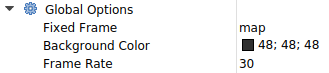
- Fixed Frame：所有帧参考的帧的名称，坐标都是相对的，这个就是告诉RVIZ你是相对谁的，一般是设置成map或者odom
- rame Rate：用于设置更新 3D 视图的最大频率。

2. 网格  
用于可视化通常与地板平面相关联的网格  
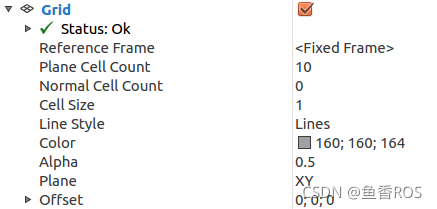
- Reference frame：帧用作网格坐标参考（通常：）
- Plane cell count: 单元格中网格的大小
- Normal cell count：在沿垂直于叶栅平面的网格数（正常：0）
- Cell size：每个网格单元的尺寸（以米为单位）
- Plane：标识网格平面的两个轴

**机器人模型**

根据 URDF 模型的描述来可视化机器人的模型。  
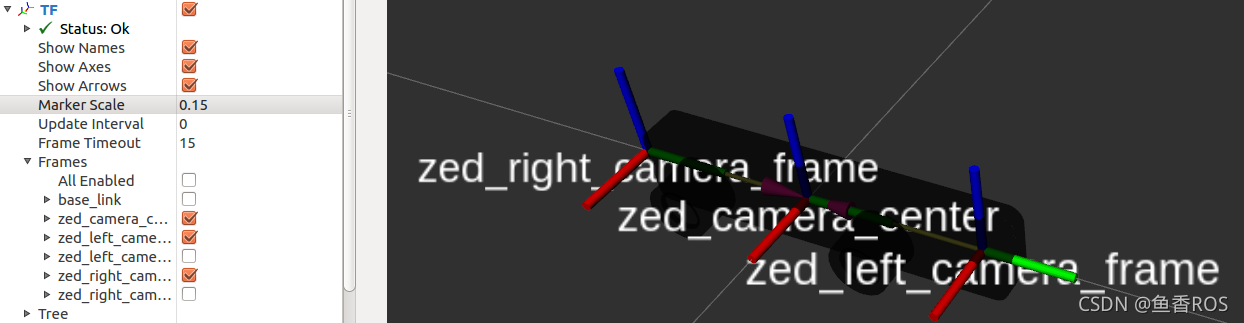
- Visual enabled: 启用/禁用模型的 3D 可视化
- Description Source：机器人模型文件的来源，可以在File和Topic之间进行选择
- Description Topic: 机器人模型文件所在的话题

**TF**

可视化构成 TF 广播的所有帧的位置和方向   

- Marker Scale: 将字和坐标系标识调整的小一些，使其更加可见且不那么混乱
- Update interval：以秒为单位的TF广播更新时间

最佳实践，勾选你想看的Frames，直观的看到两个坐标之间的关系

## 调试工具-RQT
RQT是一个GUI框架，通过插件的方式实现了各种各样的界面工具。

RQT就像插座，任何电器只要符合插座的型号就可以插上去工作。

>下节的bag话题录制的存储格式也是插件式的。

**使用RQT**  
```
rqt
```
**选择插件**  
这里我们可以选择现有的几个RQT插件来试一试，可以看到和话题、参数、服务、动作四大通信组件相关的工具都有，还有一些可视化、日志和系统计算图等相关的。
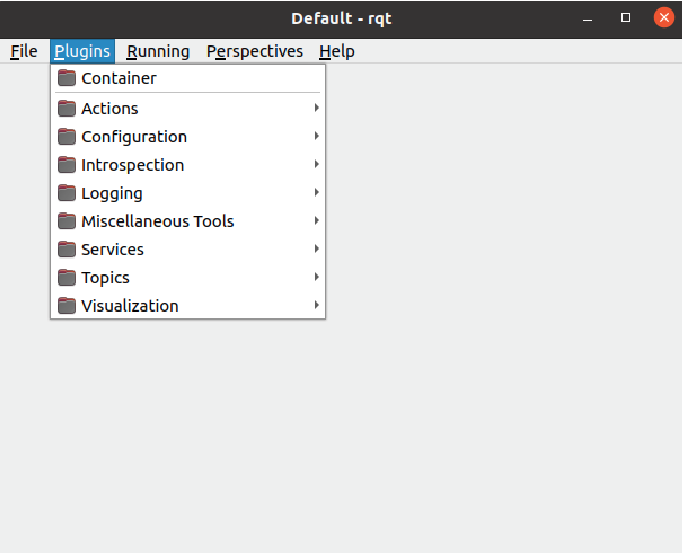  
Introspection / Node Graph  
查看节点和节点之间的关系  
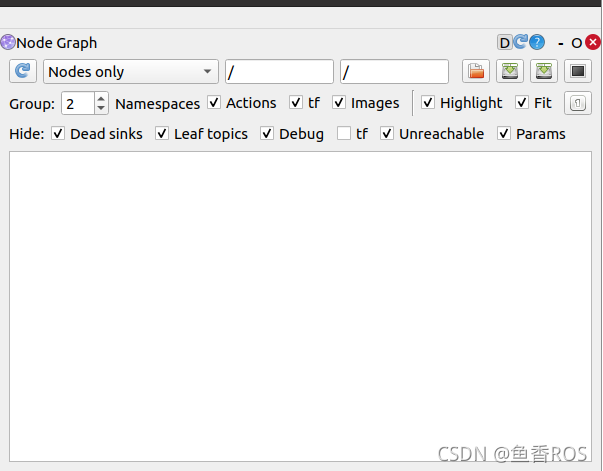  
Introspection / Process Monitor  
这个插件可以看到所有与ROS2相关的进程    
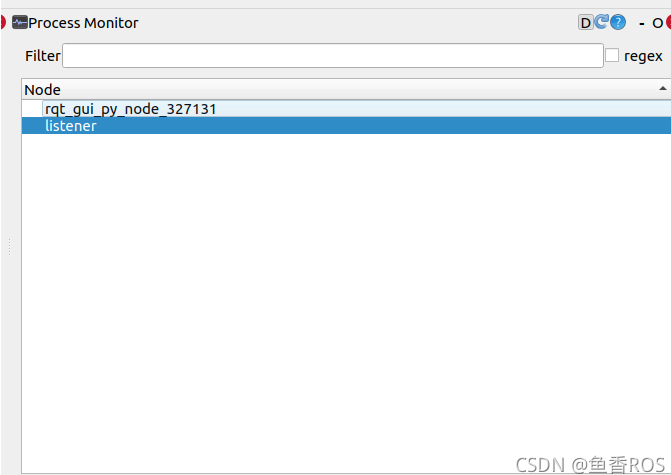   
Topic/ Message Publisher   
可以图形化发布话题数据   
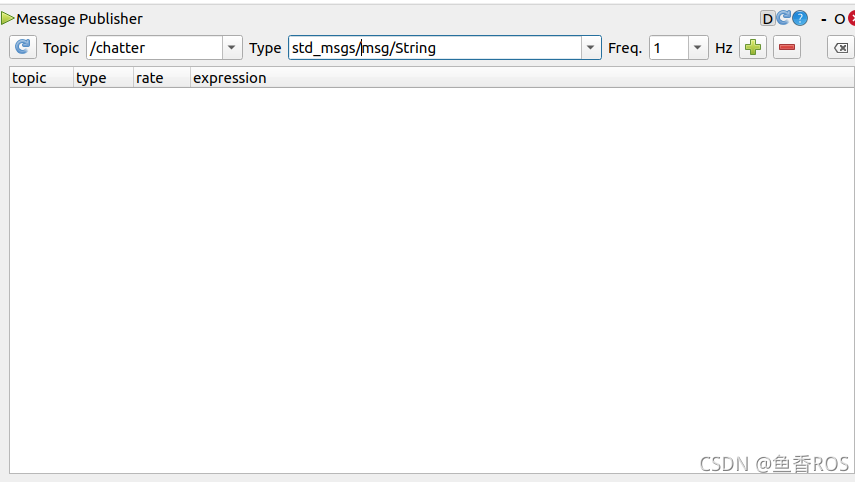  
Service /Service Caller  
图形化调用服务工具  
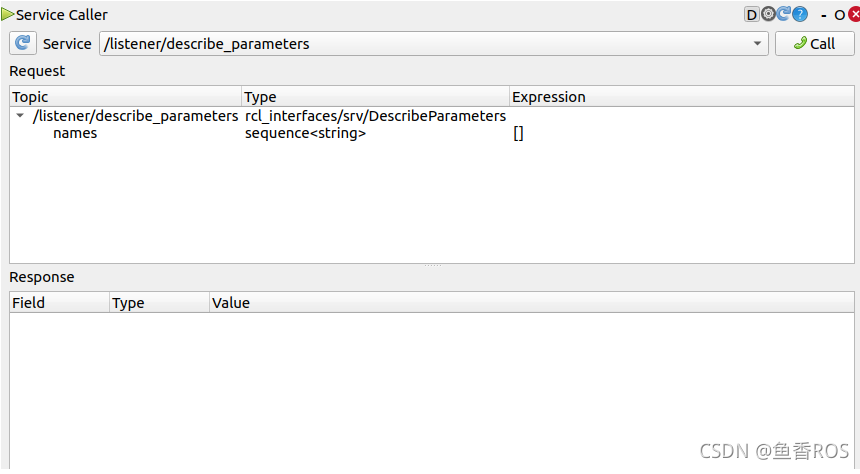  
Visualization / Image View  
看图像话题数据的Image View  
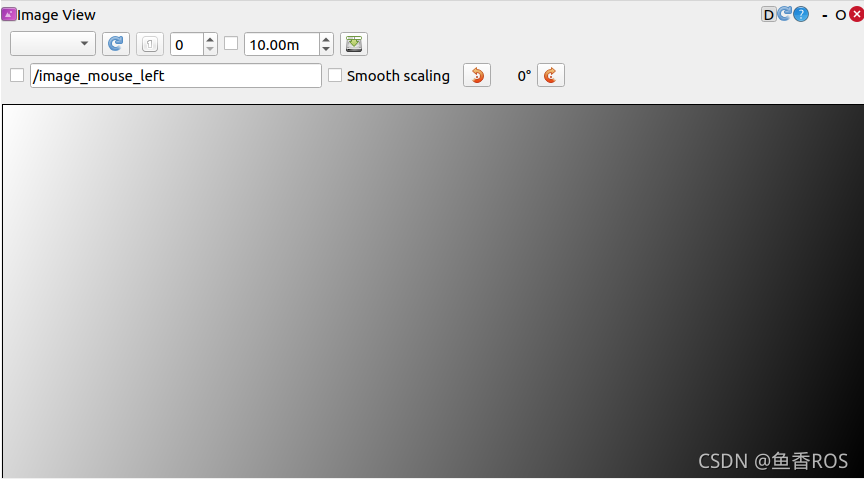  
Visualization / MatPlot  
话题数据图形化工具MqtPlot，用这个工具来调PID的  
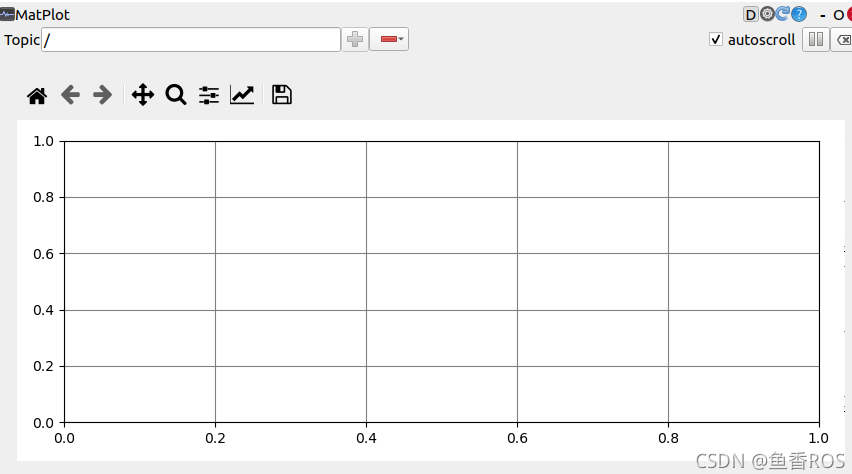  
Configuration / Parameter Reconfigure  
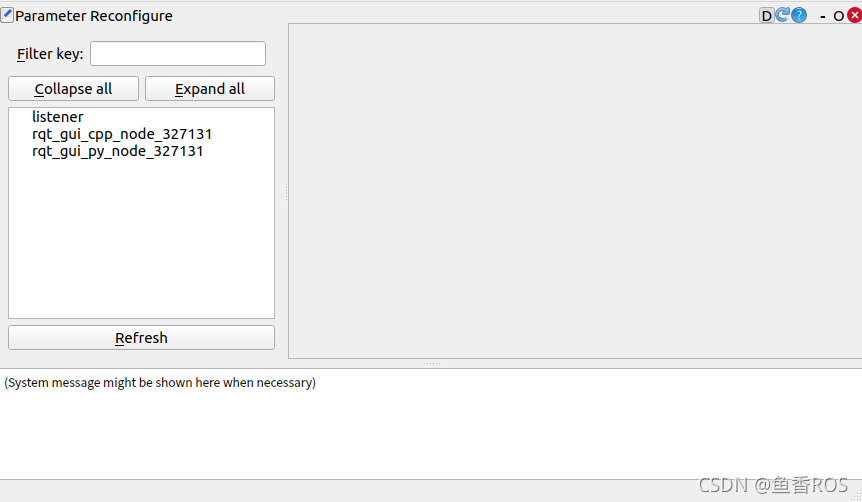

## 数据录播工具-rosbag2
ROS2中常用的一个CLI工具——rosbag2，这个工具用于记录话题的数据

可以使用这个指令将话题数据存储为文件 ，后续我们无需启动节点，直接可以将bag文件里的话题数据发布出来

>这个工具在我们做一个真实机器人的时候非常有用，比如我们录制一段机器人发生问题的话题数据，录制完成后可以多次发布出来进行测试和实验，也可以将话题数据分享给别人用于验证算法等。

### bag工具使用
使用bag工具来记录话题数据，并二次重放

**安装**  
当我们安装ROS2的时候，这个命令行工具已经为我们自动安装了，这里我们就不需要再次安装

**记录**
```
运行talker节点
ros2 run demo_nodes_cpp talker

记录(topic-name 为话题名字)
ros2 bag record topic-name

记录多个话题的数据
ros2 bag record topic-name1 topic-name2

记录所有话题
ros2 bag record -a

-o name 自定义输出文件的名字
ros2 bag record -o file-name topic-name
```

**录制chatter**  
```
运行talker节点
ros2 run demo_nodes_cpp talker

进行话题数据的录制
ros2 bag record /chatter
```
停止录制,直接在终端中使用Ctrl+C指令打断录制即可

接着你会在终端中发现多处一个文件夹，名字叫做rosbag2_xxxxxx.db3

打开文件夹，可以看到内容  
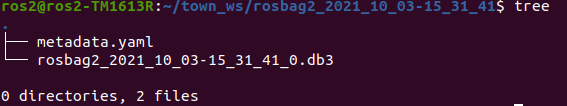  

**查看**  
查看录制出话题的信息，包括话题记录的时间，大小，类型，数量
```
ros2 bag info 
```
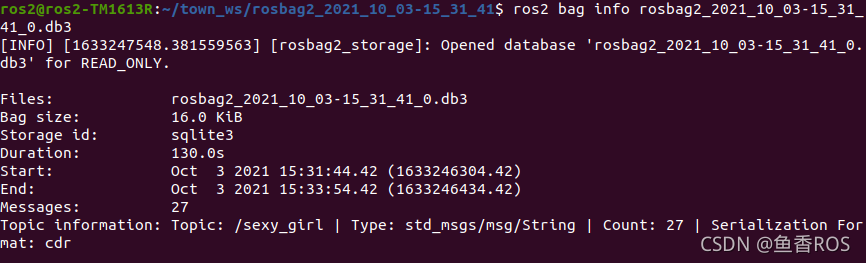

**播放**
```
播放话题数据
ros2 bag play xxx.db3

使用ros2的topic的指令来查看数据
ros2 topic echo /chatter

倍速播放 -r
-r 10,就是10倍速播放话题
ros2 bag play rosbag2_2021_10_03-15_31_41_0.db3 -r 10

循环播放 -l
ros2 bag play rosbag2_2021_10_03-15_31_41_0.db3 -l

播放单个话题
ros2 bag play rosbag2_2021_10_03-15_31_41_0.db3 --topics /chatter
```

## 兼容仿真工具-Gazebo
RVIZ2是用来可视化数据的软件，核心要义是将数据展示出来（我们不生产数据只做数据的搬运工）

而Gazebo是用于模拟真实环境生产数据的（我们不搬运数据只做数据的生产者）

Gazebo 是一个独立的应用程序，可以独立于 ROS 或 ROS 2 使用

Gazebo与ROS 版本的集成是通过一组叫做gazebo_ros_pkgs的包完成的

**两轮差速小demo**
```
安装gazebo
sudo apt install gazebo

安装ROS2的两轮差速功能包
sudo apt install ros-humble-gazebo-*

运行两轮差速demo
gazebo /opt/ros/humble/share/gazebo_plugins/worlds/gazebo_ros_diff_drive_demo.world 

通过下面的指令可看到话题和话题的类型，把目光放到这个话题/demo/cmd_demo,下面我们就通过这个话题来控制小车动起来
ros2@ros2-TM1613R:~$ ros2 topic list -t
/clock [rosgraph_msgs/msg/Clock]
/demo/cmd_demo [geometry_msgs/msg/Twist]
/demo/odom_demo [nav_msgs/msg/Odometry]
/parameter_events [rcl_interfaces/msg/ParameterEvent]
/rosout [rcl_interfaces/msg/Log]
/tf [tf2_msgs/msg/TFMessage]

让小车前进
ros2 topic pub /demo/cmd_demo geometry_msgs/msg/Twist "{linear: {x: 0.2,y: 0,z: 0},angular: {x: 0,y: 0,z: 0}}"
```

# 系统文件级
文件系统级主要由以下几个核心部分构成：
- 工作空间

- 包

- 包清单

- 消息/服务/动作类型

- 功能包集

- 构建系统配置文件

## ROS1

### 工作空间
```
my_robot_ws/       # 工作空间根目录 (名称自定义，通常以 `_ws` 结尾)
├── src/                   # 源代码空间 (Source Space)
│   ├── CMakeLists.txt     # 顶层CMakeLists.txt (由 `catkin_init_workspace` 生成)
│   ├── package_1/
│   ├── package_2/
│   └── ...
├── build/                 # 编译空间 (Build Space) 
├── devel/                 # 开发空间 (Development Space)
└── install/               # 安装空间 (Install Space, 可选)
```

src：这是手动创建和放置所有ROS包（源代码）的地方。

build：由CMake/Catkin自动生成，存放编译过程中产生的中间文件（如.o目标文件、CMake的缓存等）。通常不需要手动干预此目录。

devel：编译成功后，生成的可执行文件、库文件、环境变量设置脚本等都会放在这里。在开发过程中，需要通过 source devel/setup.bash 来让终端知道这个工作空间的存在。

install：当使用 catkin_make install 或 colcon build --symlink-install 时创建，用于将可执行文件和库安装到一个独立的目录，便于发布。

### 包
```
my_package/                    # 包目录 (名称自定义)
├── CMakeLists.txt             # **构建系统配置文件**，指导如何编译本包
├── package.xml                # **包清单文件**，描述本包的元信息和依赖
├── include/my_package/        # C++头文件目录 (可选)
│   └── my_header.h
├── src/                       # C++源代码目录 (可选)
│   └── my_node.cpp
├── scripts/                   # Python脚本/节点目录 (可选)
│   └── my_python_node.py
├── msg/                       # 自定义消息类型定义目录 (可选)
│   └── MyMessage.msg
├── srv/                       # 自定义服务类型定义目录 (可选)
│   └── MyService.srv
├── action/                    # 自定义动作类型定义目录 (可选)
│   └── MyAction.action
├── launch/                    # Launch文件目录 (可选)
│   └── my_package.launch
├── config/                    # 配置文件目录 (参数配置等) (可选)
│   └── parameters.yaml
└── urdf/                      # 机器人模型文件目录 (可选)
    └── my_robot.urdf
```
创建包的命令
```text
# ROS 1 (Catkin)
cd ~/my_robot_ws/src
catkin_create_pkg my_package std_msgs roscpp rospy

# 在工作空间根目录下编译所有包
cd my_robot_ws
catkin_make
# 或
catkin build

# 编译后，必须source install空间下的setup脚本来设置环境
source devel/setup.bash

# 启动文件
roslaunch
```

当使用 catkin_make 时，构建系统会遍历整个 src 目录，读取每个包的 package.xml 和 CMakeLists.txt，然后按照依赖关系有序地编译所有包。

### 包清单
```xml
<?xml version="1.0"?>
<package format="2">
  <!-- 基本信息 -->
  <name>my_package</name>
  <version>1.0.0</version>
  <description>
    A simple package to demonstrate ROS filesystem structure.
  </description>
  <maintainer email="you@example.com">Your Name</maintainer>
  <license>BSD</license>

  <!-- 构建依赖：编译本包时需要的外部包 -->
  <buildtool_depend>catkin</buildtool_depend> <!-- ROS 1 -->

  <build_depend>roscpp</build_depend>   <!-- 编译时需要roscpp -->
  <build_depend>std_msgs</build_depend> <!-- 编译时需要std_msgs -->

  <!-- 执行依赖：本包的代码运行时需要的外部包 -->
  <exec_depend>roscpp</exec_depend>
  <exec_depend>std_msgs</exec_depend>
  <exec_depend>message_runtime</exec_depend> <!-- 如果使用了自定义消息 -->

  <!-- 其他依赖：测试依赖等 -->
  <test_depend>gtest</test_depend>
</package>
```

### 消息、服务和动作类型
消息：存储在 msg/ 目录下的 .msg 文件。定义了在主题上传输的数据结构。
```text
string first_name
string last_name
uint8 age
float32 score
```

服务：存储在 srv/ 目录下的 .srv 文件。定义了服务通信的请求和响应两部分数据结构。
```text
# 请求部分
int64 a
int64 b
---
# 响应部分
int64 sum
```

动作：存储在 action/ 目录下的 .action 文件。定义了动作通信的目标、反馈和结果三部分数据结构。
```text
# 目标定义
int32 order
---
# 结果定义
int32[] sequence
---
# 反馈定义
int32[] partial_sequence
```

要使用这些自定义类型，必须在 package.xml 和 CMakeLists.txt 中声明相应的依赖和构建规则。

### 功能包集
功能包集是一个包的集合，用于将多个相关的包组织在一起，便于统一管理和编译。它本身不包含任何代码，只有一个特殊的文件。
```
my_metapackage/           # 功能包集目录
├── CMakeLists.txt        # 一个非常简单的CMakeLists.txt
└── package.xml           # 关键：通过 <run_depend> 或 <exec_depend> 声明集合内的所有包
```

它的主要作用是作为一个逻辑分组，例如 navigation 功能包集包含了 amcl, move_base, map_server 等所有与导航相关的包

## ROS2

### 工作空间
`devel` 变为了 `install`
```
my_ros2_ws/                 # 工作空间根目录
├── src/                    # 源代码空间 (所有包都在这里)
│   ├── cpp_package/        # 一个C++包
│   ├── py_package/         # 一个Python包
│   └── ...
├── build/                  # 编译空间 (colcon生成)
├── install/                # 安装空间 (存放最终可执行文件和库)
├── log/                    # 日志空间 (colcon的构建和测试日志)
```
```text
# 创建包 ROS 2 (Ament)
cd ~/my_robot_ws/src
ros2 pkg create my_package --build-type ament_cmake --dependencies rclcpp rclpy std_msgs
# 或用于纯Python包
ros2 pkg create my_package --build-type ament_python --dependencies rclpy std_msgs

# 在工作空间根目录下编译所有包
cd my_robot_ws
colcon build

# 编译后，必须source install空间下的setup脚本来设置环境
source install/setup.bash

# 启动文件
ros2 launch
```

### C++ 包
使用 ament_cmake 作为构建类型。它的结构与传统CMake项目类似，但集成了ROS 2的依赖查找和环境设置。
```
cpp_package/
├── CMakeLists.txt              # **核心**：CMake构建指令
├── package.xml                 # **核心**：包元信息和依赖
├── include/cpp_package/        # C++头文件目录
│   └── header.h
├── src/                        # C++源文件目录
│   ├── publisher_node.cpp
│   ├── subscriber_node.cpp
│   └── ...
├── launch/                     # Launch文件目录
│   └── cpp_launch.py
└── config/                     # 配置文件目录
    └── parameters.yaml
```
====================================================

package.xml 中必须声明依赖为 `ament_cmake` 和所需的ROS 2包。
```xml
<?xml version="1.0"?>
<?xml-model href="http://download.ros.org/schema/package_format3.xsd" schematypelayout="1.0"?>
<package format="3">
  <name>cpp_package</name>
  <version>0.0.0</version>
  <description>A C++ ROS 2 package</description>
  <maintainer email="you@example.com">Your Name</maintainer>
  <license>Apache-2.0</license>

  <!-- 构建工具依赖：必须是 ament_cmake -->
  <buildtool_depend>ament_cmake</buildtool_depend>

  <!-- 构建和运行时都需要的基本依赖 -->
  <depend>rclcpp</depend>         <!-- C++客户端库 -->
  <depend>std_msgs</depend>       <!-- 标准消息类型 -->
  
  <!-- 如果使用其他消息/服务/动作 -->
  <depend>geometry_msgs</depend>
  
  <!-- 构建时需要，但运行时不需要的依赖 -->
  <!-- <build_depend>... </build_depend> -->
  
  <!-- 运行时需要，但构建时不需要的依赖 -->
  <!-- <exec_depend>... </exec_depend> -->
</package>
```
====================================================

CMakeLists.txt 这是编译C++节点的蓝图，比ROS 1的更现代和简洁。
```text
# 指定所需CMake版本
cmake_minimum_required(VERSION 3.8)
# 项目名必须与包名一致
project(cpp_package)

# 如果使用C++17标准
if(NOT CMAKE_CXX_STANDARD)
  set(CMAKE_CXX_STANDARD 17)
endif()

# 查找构建所需的依赖包
find_package(ament_cmake REQUIRED)
find_package(rclcpp REQUIRED)
find_package(std_msgs REQUIRED)

# 将源代码编译为可执行节点
add_executable(talker src/publisher_node.cpp)
# 为节点指定链接库和依赖
ament_target_dependencies(talker rclcpp std_msgs)

add_executable(listener src/subscriber_node.cpp)
ament_target_dependencies(listener rclcpp std_msgs)

# 安装可执行文件到install/lib/<pkg_name>目录
install(TARGETS
  talker
  listener
  DESTINATION lib/${PROJECT_NAME})

# 安装Launch文件
install(DIRECTORY launch
  DESTINATION share/${PROJECT_NAME})

# 安装配置文件
install(DIRECTORY config
  DESTINATION share/${PROJECT_NAME})

# 导出包的依赖，以便其他包能找到它
ament_export_dependencies(ament_cmake rclcpp std_msgs)

# 最终调用此宏，生成必要的安装脚本
ament_package()
```

### Python包
使用 ament_python 作为构建类型。它更轻量，主要依赖于Python的 setuptools  
`CMakeLists.txt` 改为了 `setup.py`和`setup.cfg`  
`src/ 和 include/ 目录` 改为了	`一个与包同名的Python模块目录`  

```
py_package/
├── setup.py                   # **核心**：Python构建和安装指令
├── setup.cfg                  # 包配置文件
├── package.xml                # **核心**：包元信息和依赖
├── py_package/                # **与包同名的Python模块目录**
│   ├── __init__.py
│   ├── node_publisher.py
│   ├── node_subscriber.py
│   └ --> ...
├── resource/                  # 资源文件目录
│   └── py_package
├── test/                      # 测试目录 (可选)
│   └── test_copyright.py
├── launch/                    # Launch文件目录
│   └── py_launch.py
└── config/                    # 配置文件目录
    └── parameters.yaml
```
====================================================

package.xml 必须声明依赖为 `ament_python`。
```xml
<?xml version="1.0"?>
<?xml-model href="http://download.ros.org/schema/package_format3.xsd" schematypelayout="1.0"?>
<package format="3">
  <name>py_package</name>
  <version>0.0.0</version>
  <description>A Python ROS 2 package</description>
  <maintainer email="you@example.com">Your Name</maintainer>
  <license>Apache-2.0</license>

  <!-- 构建工具依赖：必须是 ament_python -->
  <buildtool_depend>ament_python</buildtool_depend>

  <!-- 运行时依赖 -->
  <depend>rclpy</depend>          <!-- Python客户端库 -->
  <depend>std_msgs</depend>       <!-- 标准消息类型 -->
  <depend>geometry_msgs</depend>

  <!-- 测试依赖 -->
  <test_depend>ament_copyright</test_depend>
  <test_depend>ament_flake8</test_depend>
</package>
```
====================================================

setup.py 这是Python包的“构建脚本”，它定义了如何安装你的Python代码和脚本。
```py
from setuptools import find_packages, setup

package_name = 'py_package'

setup(
    name=package_name,
    version='0.0.0',
    packages=find_packages(exclude=['test']), # 自动找到所有Python包
    data_files=[
        # 安装package.xml文件
        ('share/ament_index/resource_index/packages',
            ['resource/' + package_name]),
        ('share/' + package_name, ['package.xml']),
        # 安装Launch文件
        ('share/' + package_name + '/launch', ['launch/py_launch.py']),
        # 安装配置文件
        ('share/' + package_name + '/config', ['config/parameters.yaml']),
    ],
    install_requires=['setuptools'],
    zip_safe=True,
    maintainer='Your Name',
    maintainer_email='you@example.com',
    description='A Python ROS 2 package',
    license='Apache-2.0',
    tests_require=['pytest'],
    # 关键：将你的Python节点注册为控制台脚本
    entry_points={
        'console_scripts': [
            'talker = py_package.node_publisher:main',
            'listener = py_package.node_subscriber:main',
        ],
    },
)
```
====================================================

setup.cfg 一个简单的配置文件，指示setuptools将资源文件包含在包中。
```text
[develop]
script_dir=$base/lib/py_package
[install]
install_scripts=$base/lib/py_package
```
====================================================

| 特性         | C++ 包                            | Python 包                                                  |
|--------------|----------------------------------|----------------------------------------------------------|
| 构建类型     | `ament_cmake`                    | `ament_python`                                           |
| 核心配置文件 | `CMakeLists.txt`                 | `setup.py` + `setup.cfg`                                 |
| 源码组织     | `src/` 和 `include/` 目录       | 一个与包同名的Python模块目录                            |
| 节点注册     | 在 `CMakeLists.txt` 中使用 `add_executable` 和 `install` | 在 `setup.py` 的 `entry_points` 字典中注册          |
| 安装位置     | `install/lib/<package_name>/`   | `install/lib/python3.8/site-packages/` (脚本在 `lib/<package_name>/`) |
| 编译过程     | 需要编译为二进制可执行文件      | 无需编译，源码安装（但需要运行 `colcon build` 来处理安装和依赖） |
| 性能         | 高，运行效率快                   | 较低，开发效率高                                         |
| 依赖管理     | 在 `package.xml` 和 `CMakeLists.txt` 中声明 | 主要在 `package.xml` 中声明，Python依赖也可在 `setup.py` 的 `install_requires` 中 |

### 包清单
采用格式3，语法更简洁，是ROS 2与ROS 1的显著区别之一
```xml
<?xml version="1.0"?>
<?xml-model href="http://download.ros.org/schema/package_format3.xsd" schematypelayout="1.0"?> <!-- XML模式验证 -->
<package format="3">  <!-- 明确声明格式版本 -->
  <name>my_package</name>
  <version>1.0.0</version>
  <description>My ROS 2 package</description>
  <maintainer email="you@example.com">Your Name</maintainer>
  <license>Apache-2.0</license>  <!-- 常用许可证变更 -->

  <!-- 依赖声明大大简化 -->
  <buildtool_depend>ament_cmake</buildtool_depend>  <!-- 或 ament_python -->
  
  <!-- 单个<depend>标签替代了ROS 1中的多个标签 -->
  <depend>rclcpp</depend>      <!-- 等同于 build+exec+export -->
  <depend>std_msgs</depend>
  <depend>geometry_msgs</depend>

  <!-- 测试依赖 -->
  <test_depend>ament_lint_auto</test_depend>
</package>
``` 

### 其他与ROS1区别
- 构建系统  
核心工具：colcon (Collective Construction)，替代ROS 1的catkin_make/catkin build  
构建命令：colcon build  
关键特性：
  - 并行构建多个包
  - 更好的依赖处理和隔离
  - 统一的构建、测试和工作空间管理

- 启动文件
  - ROS 1：主要使用XML格式 (.launch)
  - ROS 2：Python启动文件 (.launch.py) 成为推荐标准，提供更强的编程能力和灵活性  

- 参数文件
  - 格式：YAML成为参数声明的主要格式
  - 管理：参数系统是核心功能，支持动态类型检查和生命周期管理  

- 接口定义 (.msg, .srv, .action)  
位置和语法基本保持不变，但生成代码的API更现代化。  

# 消息类型
消息类型是一个数据结构定义，它严格规定了在Topic、Service或Action中传输的数据的格式和类型。

核心概念：
- 强类型：每个消息都有明确的类型，发布者和订阅者必须使用相同的类型才能通信。

- 复合结构：消息可以由其他消息类型嵌套组成，构建出复杂的数据结构。

- 平台无关：消息有标准的序列化机制，确保在不同语言和平台间可靠传输。

## 常见消息包
|包名       	|描述	        |常用消息类型                           |
|---            |---           |---                                   |
|std_msgs	    |基础数据类型	|String, Int32, Float64, Bool, Header   |
|geometry_msgs	|几何相关	    |Twist, Pose, Point, Vector3            |
|sensor_msgs	|传感器数据	    |Image, LaserScan, Imu, PointCloud2     |
|nav_msgs	    |导航相关	    |Odometry, Path, OccupancyGrid          |
|tf2_msgs	    |坐标变换	    |TFMessage                              |
|actionlib_msgs	|动作消息	    |GoalID, GoalStatus                     |

示例：
```py
from std_msgs.msg import String
msg = String()
msg.data = "Hello ROS 2"

from sensor_msgs.msg import Image
msg = Image()
msg.height = 480
msg.width = 640
msg.encoding = "rgb8"  # 图像编码格式
```

## 消息格式

消息使用 .msg 文件定义。  
基本格式：`字段类型 字段名称`

|   ROS 2 类型   |   C++ 类型     |   Python 类型   |   描述                 |
|----------------|----------------|----------------|-----------------------|
| `bool`         | `bool`         | `bool`         | 布尔值（`true`/`false`） |
| `byte`         | `uint8_t`      | `bytes`        | 8 位无符号整数（0~255） |
| `char`         | `char`         | `str`          | 单字符（ASCII 或 Unicode） |
| `int8`         | `int8_t`       | `int`          | 8 位有符号整数（-128~127） |
| `uint8`        | `uint8_t`      | `int`          | 8 位无符号整数（0~255） |
| `int16`        | `int16_t`      | `int`          | 16 位有符号整数（-32,768~32,767） |
| `uint16`       | `uint16_t`     | `int`          | 16 位无符号整数（0~65,535） |
| `int32`        | `int32_t`      | `int`          | 32 位有符号整数（-2,147,483,648~2,147,483,647） |
| `uint32`       | `uint32_t`     | `int`          | 32 位无符号整数（0~4,294,967,295） |
| `int64`        | `int64_t`      | `int`          | 64 位有符号整数（范围极大） |
| `uint64`       | `uint64_t`     | `int`          | 64 位无符号整数（范围极大） |
| `float32`      | `float`        | `float`        | 32 位单精度浮点数 |
| `float64`      | `double`       | `float`        | 64 位双精度浮点数 |
| `string`       | `std::string`  | `str`          | 字符串（UTF-8 编码） |

特殊格式
|类型	|语法	                            |描述|
|---    |---                               |---|
|数组	|`类型[] 名称` 或 `类型[长度] 名称`	  |可变长度或固定长度数组|
|常量	|`类型 名称=值`	                     |定义常量值|

示例  
简单消息：std_msgs/String.msg
```
string data
```
python使用
```py
from std_msgs.msg import String

msg = String()
msg.data = "Hello ROS 2"
```

复合消息：geometry_msgs/Twist.msg
```
Vector3  linear
Vector3  angular
```
geometry_msgs/Vector3.msg：
```
float64 x
float64 y
float64 z
```
python使用
```py
from geometry_msgs.msg import Twist, Vector3

msg = Twist()
msg.linear = Vector3(x=1.0, y=0.0, z=0.0)  # 前进速度 1.0 m/s
msg.angular = Vector3(x=0.0, y=0.0, z=0.5)  # 旋转速度 0.5 rad/s
```

## 自定义消息
1.在包中创建msg/MyCustom.msg
```text
string first_name
string last_name
uint8 age
float32 score
string[] hobbies
bool is_student=true
```
2.修改 package.xml
```xml
<buildtool_depend>ament_cmake</buildtool_depend>
<depend>rosidl_default_generators</depend>
<member_of_group>rosidl_interface_packages</member_of_group>
```
3.修改 CMakeLists.txt
```text
find_package(rosidl_default_generators REQUIRED)

rosidl_generate_interfaces(${PROJECT_NAME}
  "msg/MyCustom.msg"
  DEPENDENCIES geometry_msgs
)
```
4.python中使用
```py
#!/usr/bin/env python3
import rclpy
from rclpy.node import Node
from std_msgs.msg import String, Int32
from geometry_msgs.msg import Twist, Point
from custom_interfaces.msg import MyCustom  # 自定义消息

class MessageExample(Node):
    def __init__(self):
        super().__init__('message_example')
        
        # 1. 创建各种消息
        self.string_msg = String()
        self.twist_msg = Twist()
        self.custom_msg = MyCustom()
        
        # 2. 填充消息数据
        self.setup_messages()
        
        # 3. 创建发布者
        self.string_pub = self.create_publisher(String, 'string_topic', 10)
        self.twist_pub = self.create_publisher(Twist, 'cmd_vel', 10)
        self.custom_pub = self.create_publisher(MyCustom, 'custom_topic', 10)
        
        self.timer = self.create_timer(1.0, self.publish_all)
    
    def setup_messages(self):
        """设置各种消息的内容"""
        # String 消息
        self.string_msg.data = "Hello World"
        
        # Twist 消息 (控制移动)
        self.twist_msg.linear.x = 0.5
        self.twist_msg.angular.z = 0.1
        
        # 自定义消息
        self.custom_msg.first_name = "John"
        self.custom_msg.last_name = "Doe"
        self.custom_msg.age = 25
        self.custom_msg.score = 95.5
        self.custom_msg.hobbies = ["robotics", "programming", "reading"]
    
    def publish_all(self):
        """发布所有消息"""
        self.string_pub.publish(self.string_msg)
        self.twist_pub.publish(self.twist_msg)
        self.custom_pub.publish(self.custom_msg)
        
        self.get_logger().info('Published all messages')

def main(args=None):
    rclpy.init(args=args)
    node = MessageExample()
    rclpy.spin(node)
    node.destroy_node()
    rclpy.shutdown()

if __name__ == '__main__':
    main()
```

# 引用资料
[Node 的讲解](https://chat.deepseek.com/share/4puxn6199bjbhfqghb)  
[Topic 的讲解](https://chat.deepseek.com/share/nejevxao832n9gnsfq)  
[Service 的讲解](https://chat.deepseek.com/share/c4kwenzifkb8ppndiw)  
[Action 的讲解](https://chat.deepseek.com/share/9l2xfaxm6t1o9zbowc)  
[Parameters 的讲解](https://chat.deepseek.com/share/xw1di8plgkiuii4t2x)  
[Launch 的讲解](https://chat.deepseek.com/share/13ca05p6k1oadrgf73)  
[接口的讲解](https://chat.deepseek.com/share/0eli6u3tz73tbbzps7)  
[差速驱动机器人](https://chat.deepseek.com/share/fpd01x35g81e7o5sue)  
[tf2](https://chat.deepseek.com/share/3vp52pyh0igocjovk1)  
[Nav2](https://chat.deepseek.com/share/g6y2rtdffw3mdoef01)  
[Moveit](https://chat.deepseek.com/share/vf8q59m2ide6lyconm)  
[SLAM](https://chat.deepseek.com/share/gh5rjn8jvxfozuib96)
